# Models evaluation - Test 4 (Bracket Closing)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()
device = "cuda"

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

brackets = "({["

brackets_ix = []

for bracket in brackets:
    brackets_ix.append(vocab[bracket])

bracket_values = torch.tensor(brackets_ix, device=device)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

print("Ix of {: ", vocab["{"], " ix of }: ", vocab["}"])
print("Ix of [: ", vocab["["], " ix of ]: ", vocab["]"])
print("Ix of (: ", vocab["("], " ix of ): ", vocab[")"])

Ix of {:  36  ix of }:  37
Ix of [:  40  ix of ]:  41
Ix of (:  38  ix of ):  39


In [2]:
def get_batch_ex4(batch_size, bracket_values, vocab, buffer_size=50, device="cuda"):
    #Note - buffer size and copy size are IDENTICAL in this task.
    # buffer_size = 500 means that the model has to READ and WRITE 500 tokens.

    brackets_tensor = bracket_values[torch.randint(len(bracket_values), size=(batch_size, buffer_size), device=device)]
    copy_tensor = torch.flip(brackets_tensor, dims=[1])
    copy_tensor = copy_tensor + 1 # We exploit a cool vocab trick - the closed brackets are just the next index.
    

    marker_tensor = torch.full(
        (batch_size, 1),
        vocab["<STARTTASK>"],
        device=device,
    )

    ready_tensor = torch.cat([brackets_tensor, marker_tensor], dim=-1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor

def evaluate_ex4(model, bracket_values, buffer_size, total_batches, batch_size, vocab, teacher_forcing=True, diagnostic=False):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0
    with torch.no_grad():
        model.eval()
        for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

            batch, targets = get_batch_ex4(batch_size, bracket_values, vocab, buffer_size) #targets = (batch, seq)
            model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

            if teacher_forcing==False:
                logits = model.predict_inference(
                    x=batch,
                    vocab=vocab,
                    max_len=buffer_size-1
                )
            else:
                logits = model.forward(batch, model_targets) # (batch, seq, emb)
            tokens = torch.argmax(logits, dim=2) # (batch, seq)

            difference = targets - tokens #we'll get some number where the numbers are not the same

            difference = (difference !=0).float()

            num_elements = buffer_size * batch_size

            num_different = torch.sum(difference)

            avg_difference = num_different / num_elements

            avg_difference_sum = avg_difference_sum + avg_difference.item()

            if diagnostic==True and batch_num == total_batches:
                print("True targets: ", targets)
                print("Predictions: ", tokens)

        model.train()

    return avg_difference_sum / (total_batches+1)



In [3]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Bracket closing task')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex4(model, batch_size, total_batches, test_batches, bracket_values, buffer_size, opt, test_break, model_name,
                     steps_history, train_history, test_history, vocab):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(25, buffer_size)

        batch, targets = get_batch_ex4(batch_size, bracket_values, vocab, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex4")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex4(batch_size, bracket_values, vocab, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [4]:
import custom_models

hid=256
m_hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

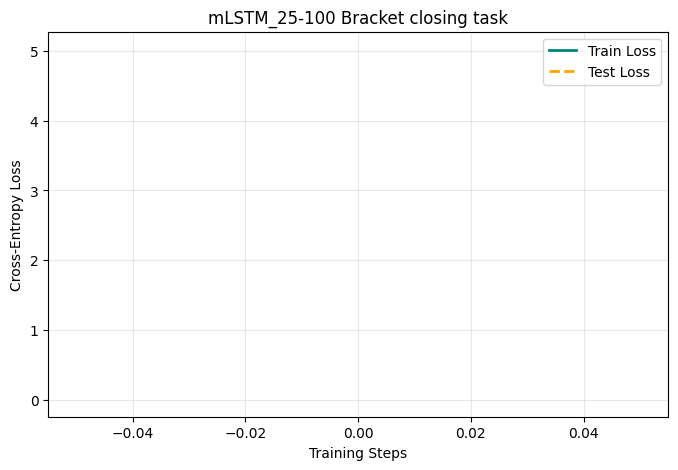

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 5.0234


  0%|          | 0/10 [00:00<?, ?it/s]

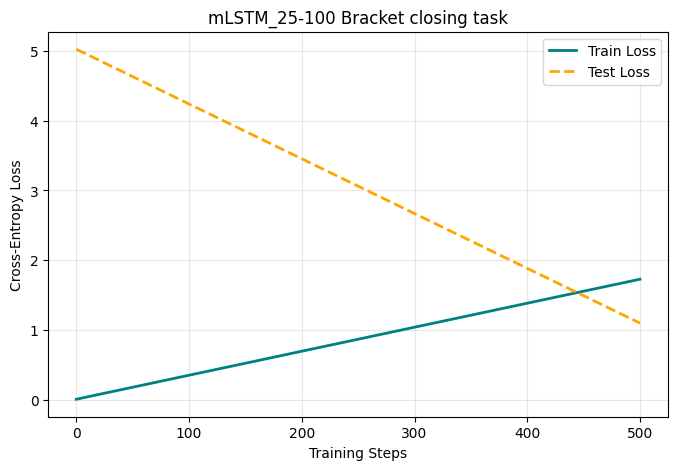

STEP: 500 | TRAIN LOSS: 1.7290 | TEST LOSS: 1.1002


  0%|          | 0/10 [00:00<?, ?it/s]

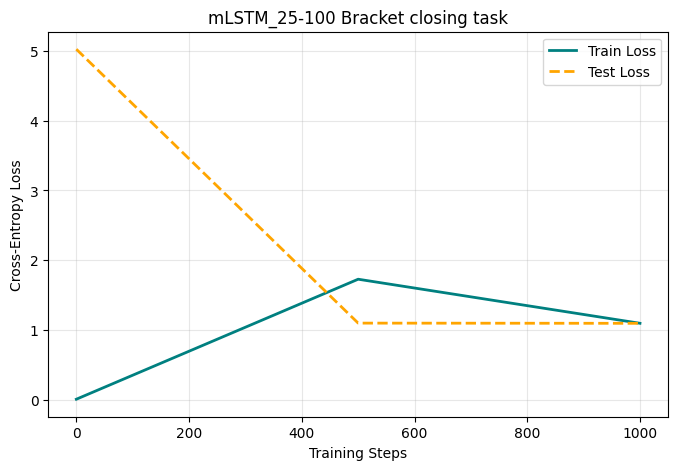

STEP: 1000 | TRAIN LOSS: 1.0978 | TEST LOSS: 1.0973


  0%|          | 0/10 [00:00<?, ?it/s]

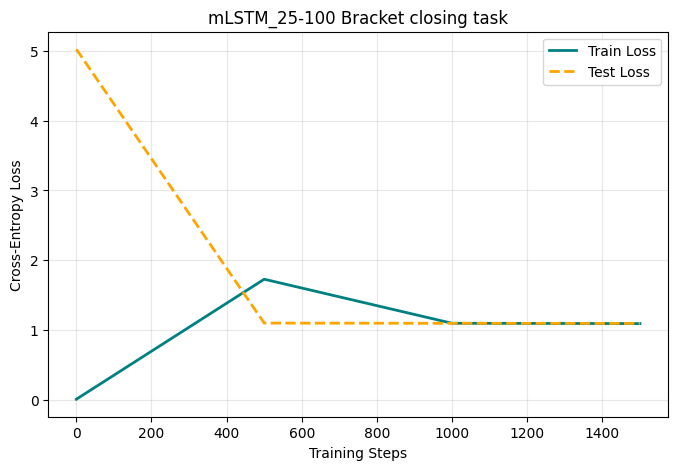

STEP: 1500 | TRAIN LOSS: 1.0933 | TEST LOSS: 1.0956


  0%|          | 0/10 [00:00<?, ?it/s]

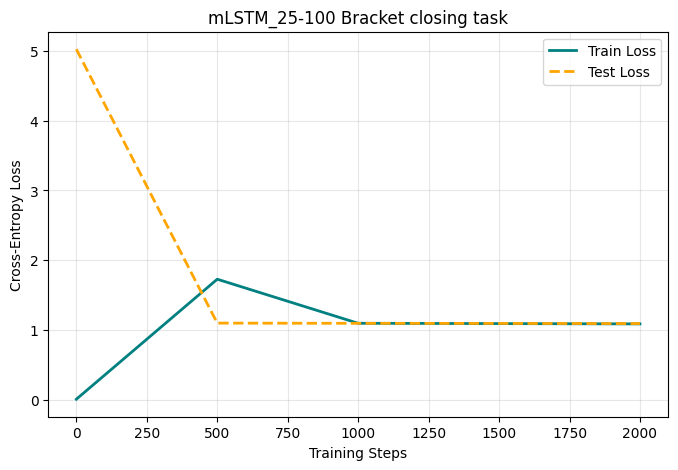

STEP: 2000 | TRAIN LOSS: 1.0889 | TEST LOSS: 1.0936


  0%|          | 0/10 [00:00<?, ?it/s]

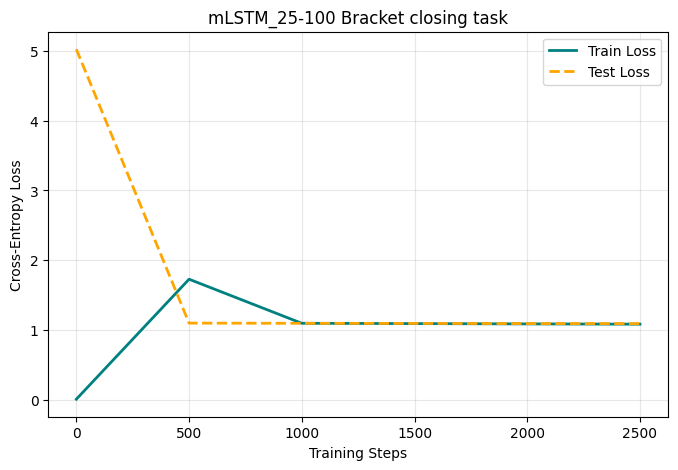

STEP: 2500 | TRAIN LOSS: 1.0851 | TEST LOSS: 1.0931


  0%|          | 0/10 [00:00<?, ?it/s]

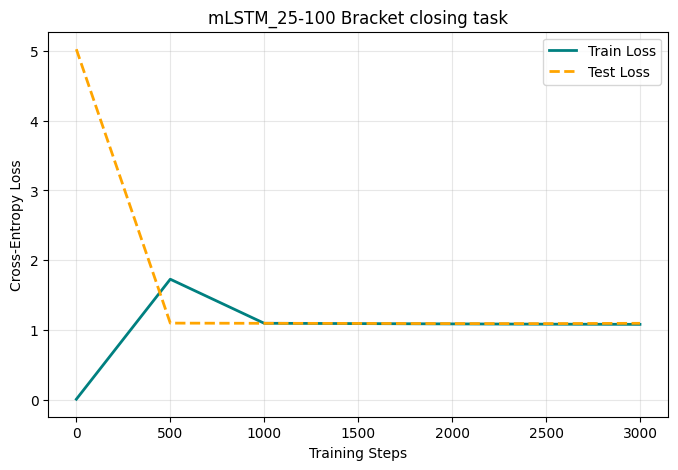

STEP: 3000 | TRAIN LOSS: 1.0824 | TEST LOSS: 1.0974


  0%|          | 0/10 [00:00<?, ?it/s]

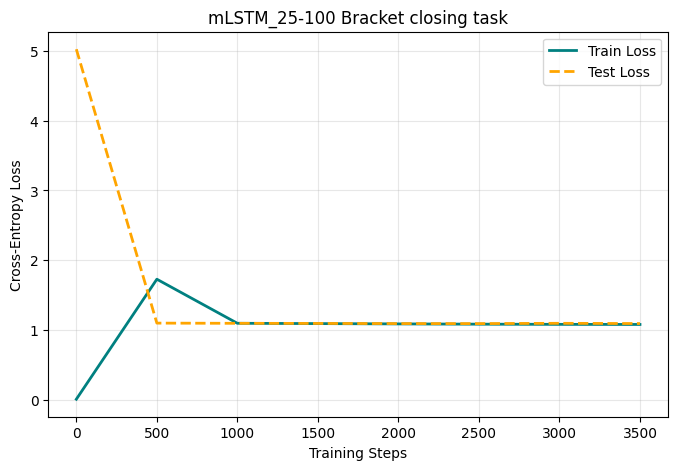

STEP: 3500 | TRAIN LOSS: 1.0808 | TEST LOSS: 1.0939


  0%|          | 0/10 [00:00<?, ?it/s]

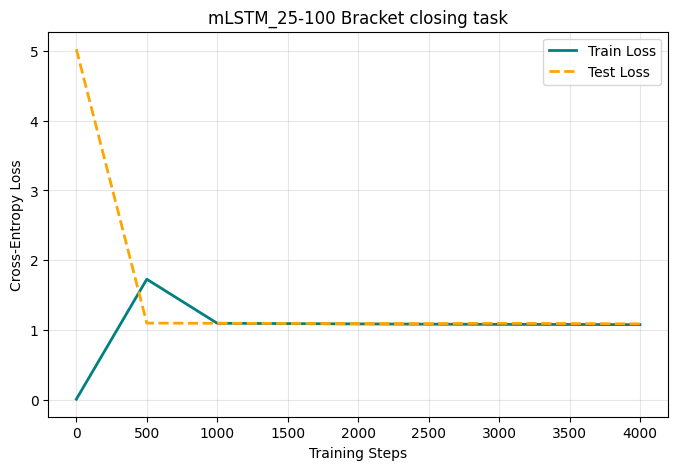

STEP: 4000 | TRAIN LOSS: 1.0781 | TEST LOSS: 1.0893


  0%|          | 0/10 [00:00<?, ?it/s]

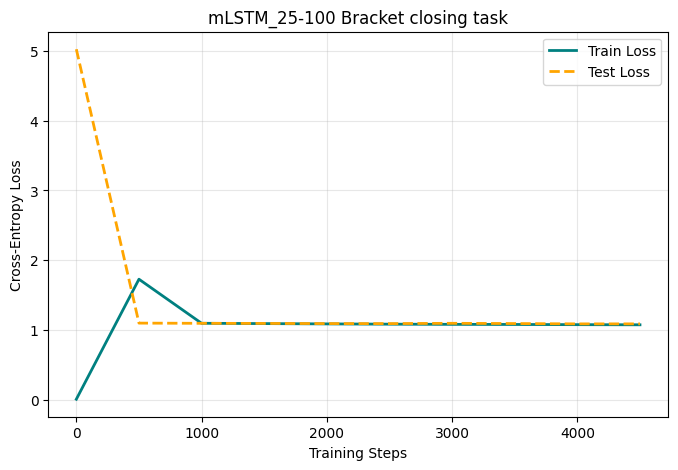

STEP: 4500 | TRAIN LOSS: 1.0761 | TEST LOSS: 1.0894


  0%|          | 0/10 [00:00<?, ?it/s]

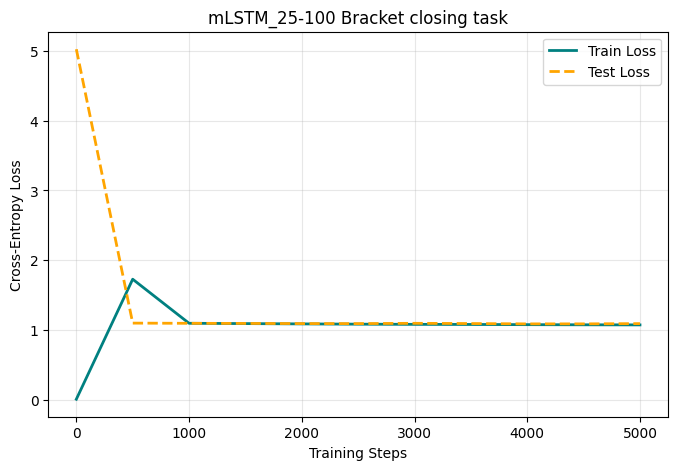

STEP: 5000 | TRAIN LOSS: 1.0747 | TEST LOSS: 1.0929


  0%|          | 0/10 [00:00<?, ?it/s]

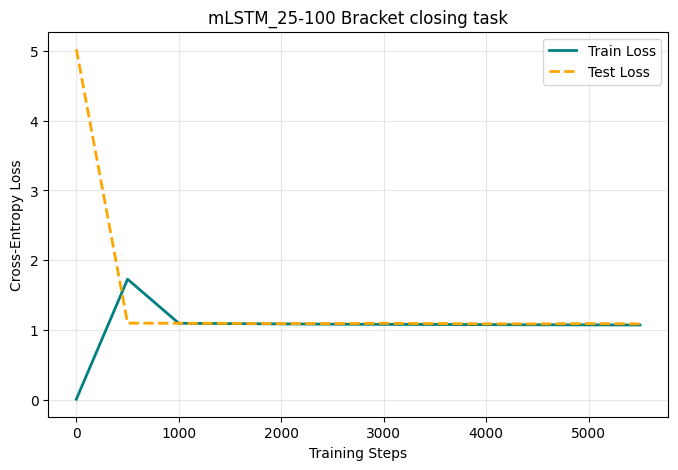

STEP: 5500 | TRAIN LOSS: 1.0732 | TEST LOSS: 1.0889


  0%|          | 0/10 [00:00<?, ?it/s]

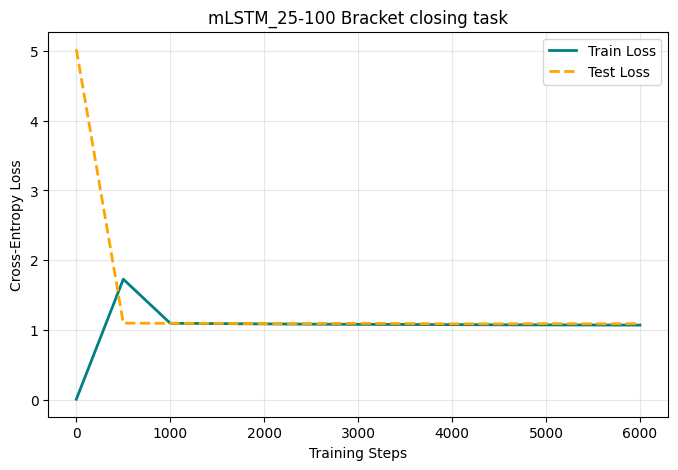

STEP: 6000 | TRAIN LOSS: 1.0717 | TEST LOSS: 1.0919


  0%|          | 0/10 [00:00<?, ?it/s]

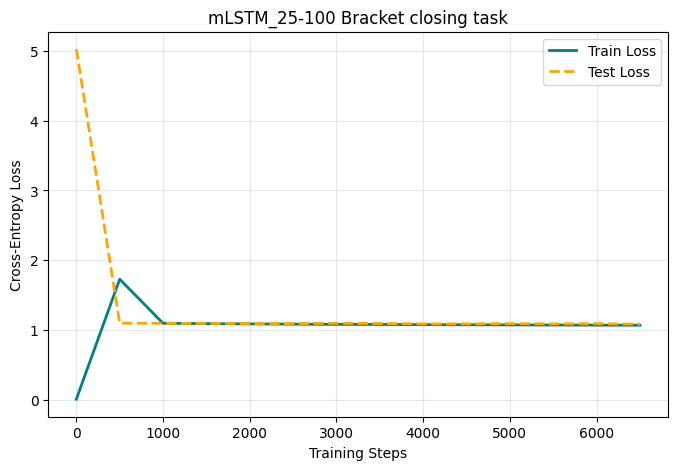

STEP: 6500 | TRAIN LOSS: 1.0700 | TEST LOSS: 1.0848


  0%|          | 0/10 [00:00<?, ?it/s]

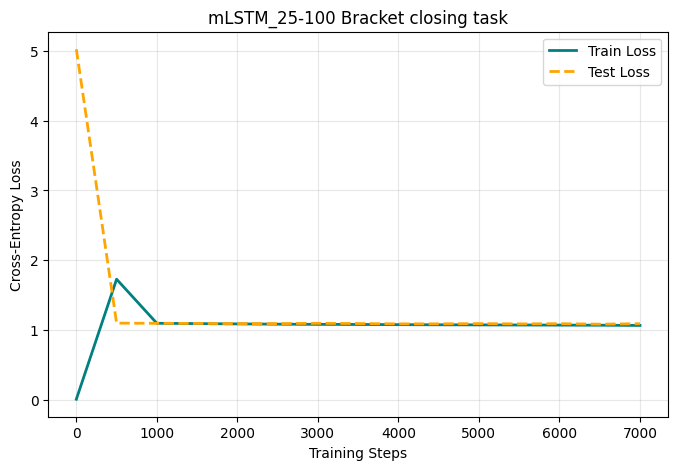

STEP: 7000 | TRAIN LOSS: 1.0669 | TEST LOSS: 1.0915


In [5]:
run_training_ex4(model=mLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_mLSTM, 
                 test_break=500, 
                 model_name="mLSTM_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

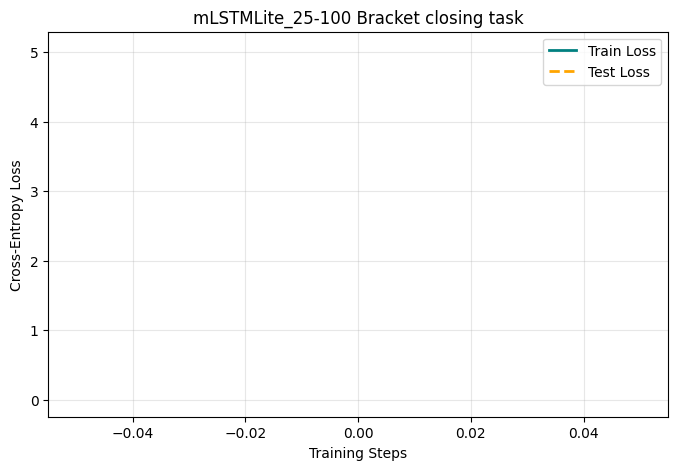

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 5.0430


  0%|          | 0/10 [00:00<?, ?it/s]

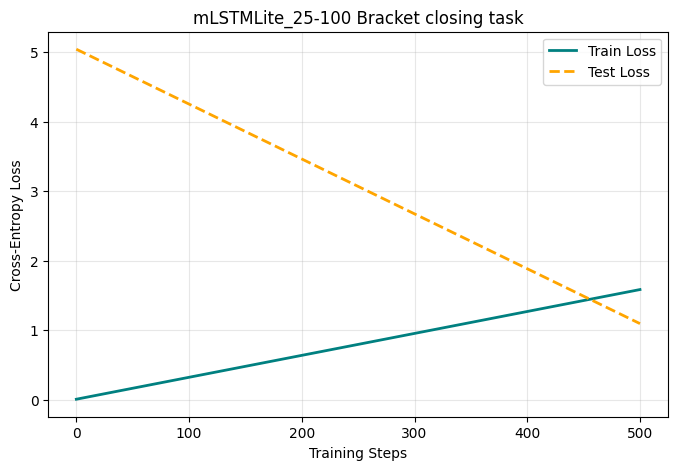

STEP: 500 | TRAIN LOSS: 1.5870 | TEST LOSS: 1.0972


  0%|          | 0/10 [00:00<?, ?it/s]

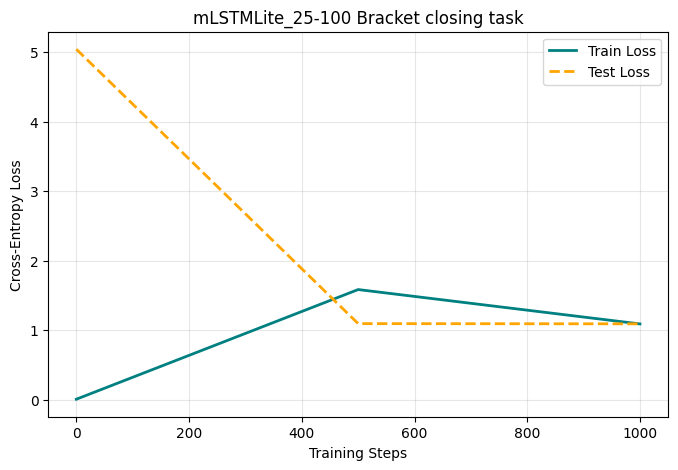

STEP: 1000 | TRAIN LOSS: 1.0929 | TEST LOSS: 1.0942


  0%|          | 0/10 [00:00<?, ?it/s]

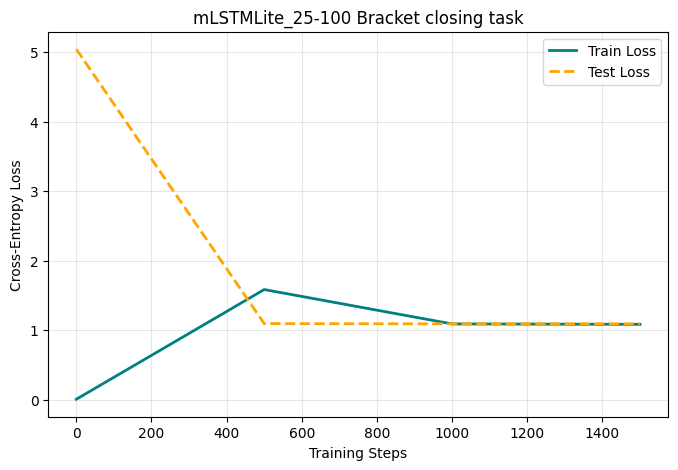

STEP: 1500 | TRAIN LOSS: 1.0868 | TEST LOSS: 1.0936


  0%|          | 0/10 [00:00<?, ?it/s]

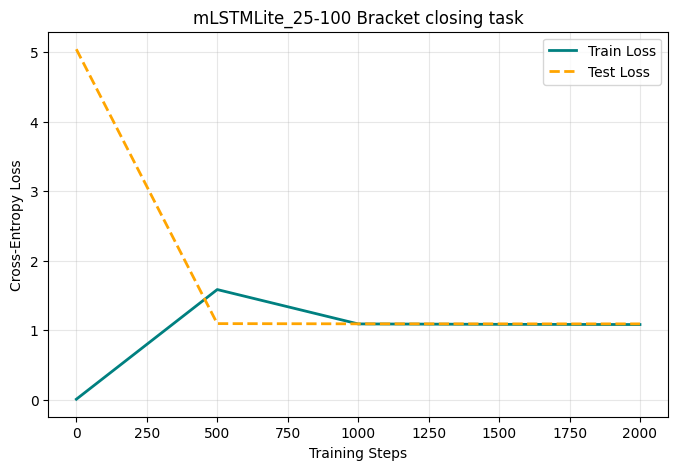

STEP: 2000 | TRAIN LOSS: 1.0840 | TEST LOSS: 1.0936


  0%|          | 0/10 [00:00<?, ?it/s]

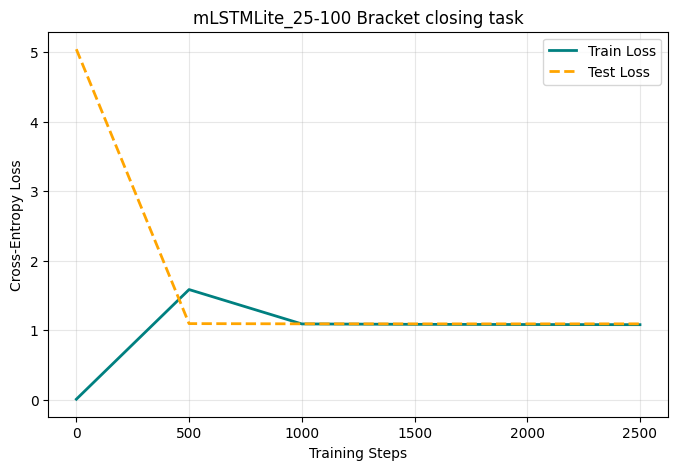

STEP: 2500 | TRAIN LOSS: 1.0821 | TEST LOSS: 1.0940


  0%|          | 0/10 [00:00<?, ?it/s]

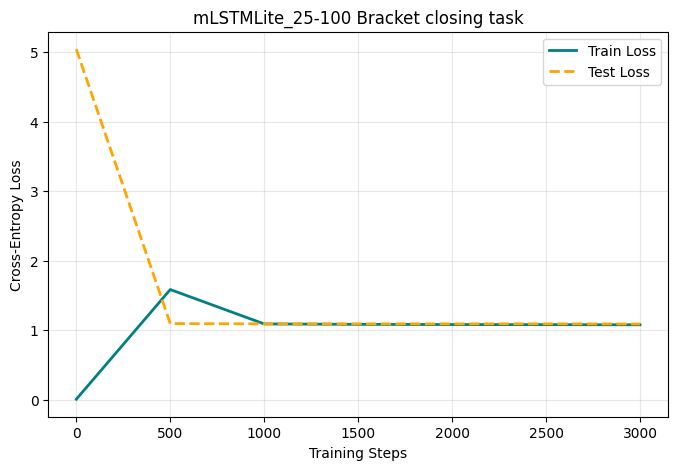

STEP: 3000 | TRAIN LOSS: 1.0803 | TEST LOSS: 1.0914


  0%|          | 0/10 [00:00<?, ?it/s]

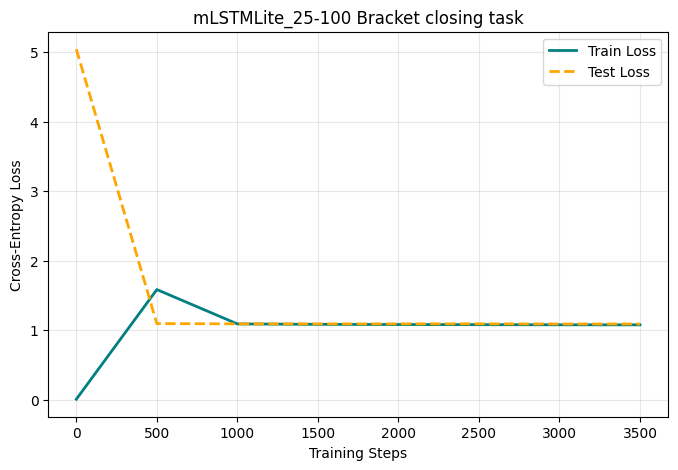

STEP: 3500 | TRAIN LOSS: 1.0797 | TEST LOSS: 1.0918


  0%|          | 0/10 [00:00<?, ?it/s]

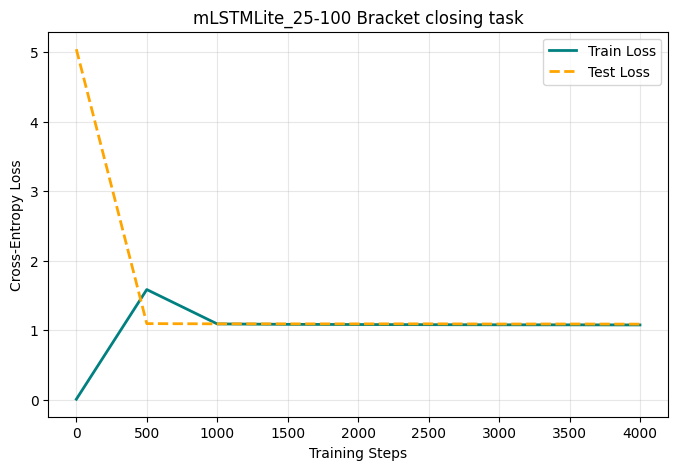

STEP: 4000 | TRAIN LOSS: 1.0783 | TEST LOSS: 1.0897


  0%|          | 0/10 [00:00<?, ?it/s]

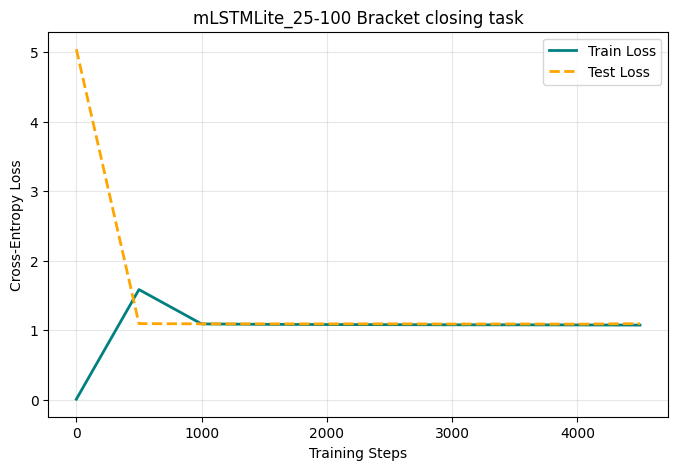

STEP: 4500 | TRAIN LOSS: 1.0762 | TEST LOSS: 1.0969


  0%|          | 0/10 [00:00<?, ?it/s]

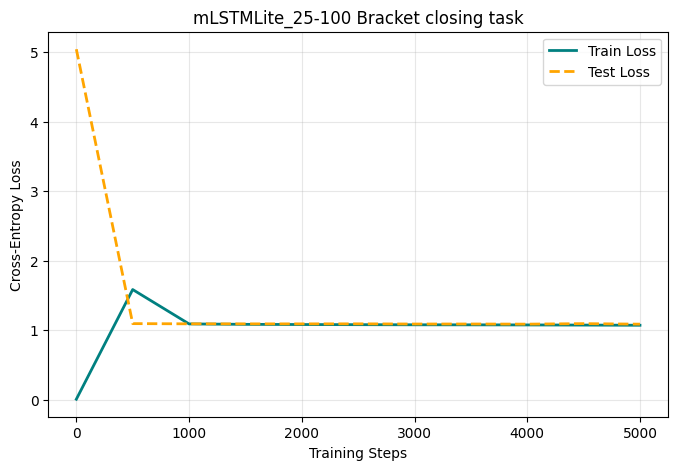

STEP: 5000 | TRAIN LOSS: 1.0737 | TEST LOSS: 1.0895


  0%|          | 0/10 [00:00<?, ?it/s]

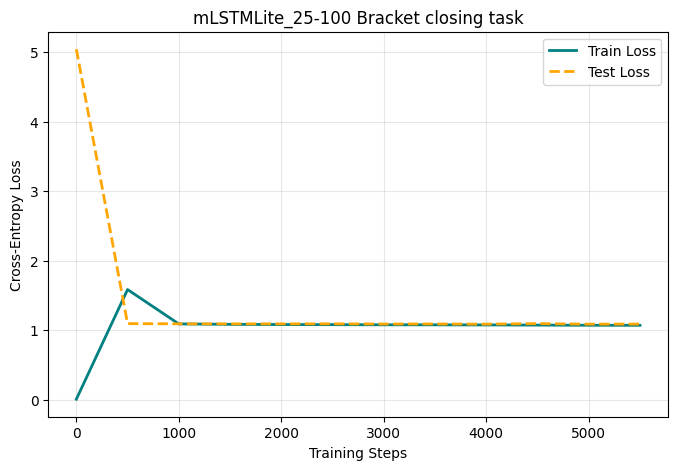

STEP: 5500 | TRAIN LOSS: 1.0729 | TEST LOSS: 1.0904


  0%|          | 0/10 [00:00<?, ?it/s]

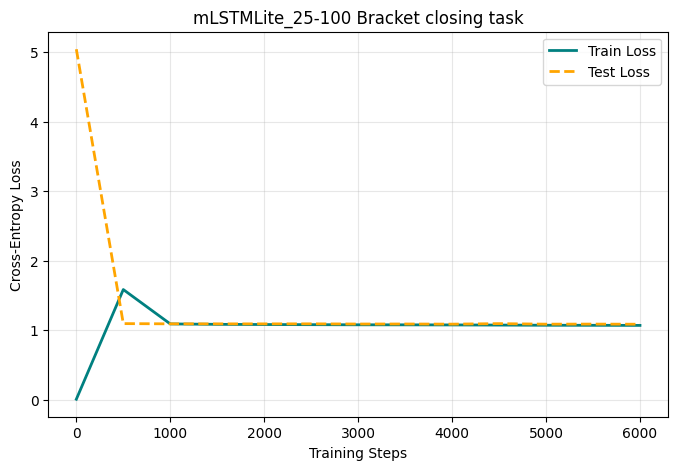

STEP: 6000 | TRAIN LOSS: 1.0716 | TEST LOSS: 1.0885


  0%|          | 0/10 [00:00<?, ?it/s]

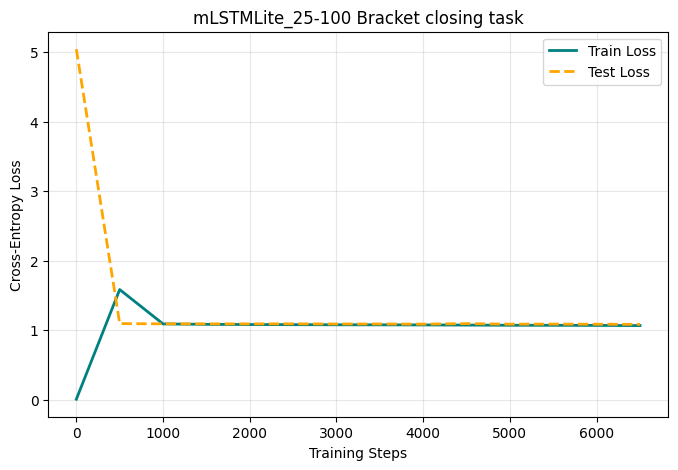

STEP: 6500 | TRAIN LOSS: 1.0688 | TEST LOSS: 1.0864


  0%|          | 0/10 [00:00<?, ?it/s]

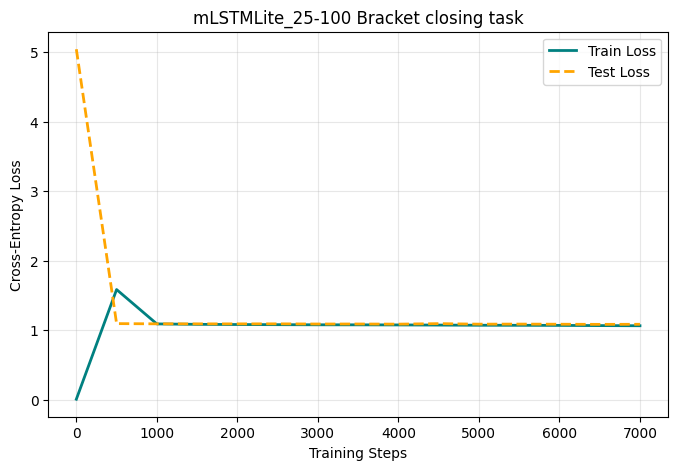

STEP: 7000 | TRAIN LOSS: 1.0666 | TEST LOSS: 1.0877


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=mLSTMLite_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_mLSTMLite, 
                 test_break=500, 
                 model_name="mLSTMLite_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

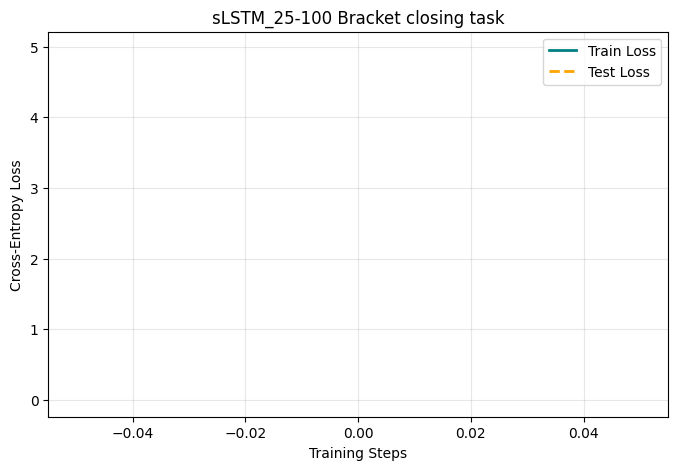

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9641


  0%|          | 0/10 [00:00<?, ?it/s]

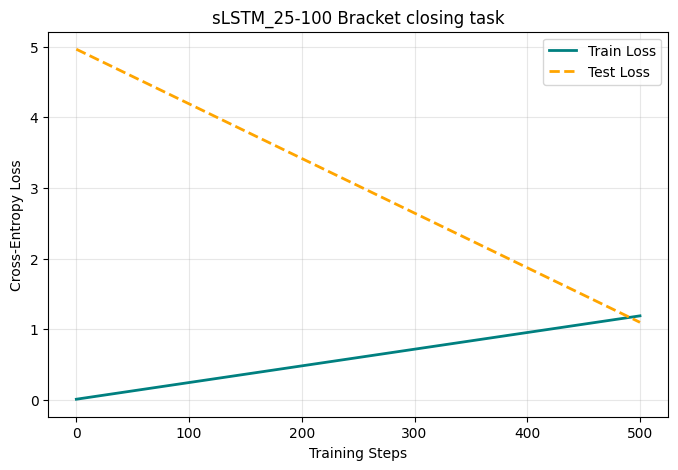

STEP: 500 | TRAIN LOSS: 1.1902 | TEST LOSS: 1.0982


  0%|          | 0/10 [00:00<?, ?it/s]

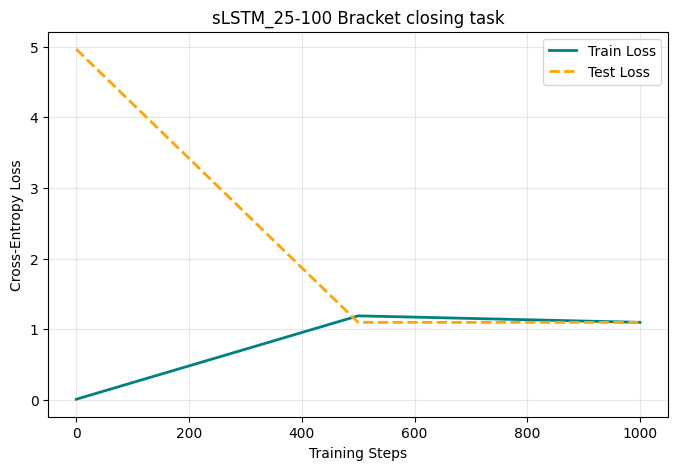

STEP: 1000 | TRAIN LOSS: 1.0982 | TEST LOSS: 1.0980


  0%|          | 0/10 [00:00<?, ?it/s]

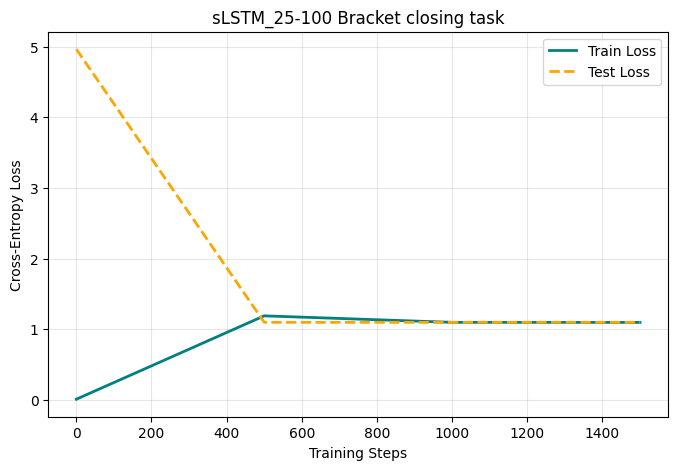

STEP: 1500 | TRAIN LOSS: 1.0972 | TEST LOSS: 1.0989


  0%|          | 0/10 [00:00<?, ?it/s]

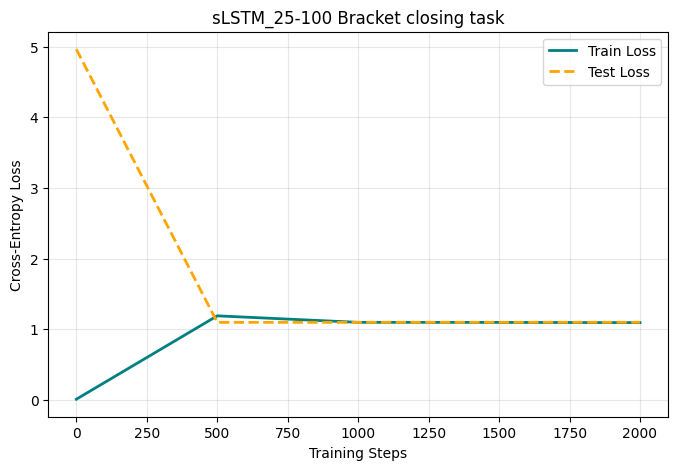

STEP: 2000 | TRAIN LOSS: 1.0945 | TEST LOSS: 1.0990


  0%|          | 0/10 [00:00<?, ?it/s]

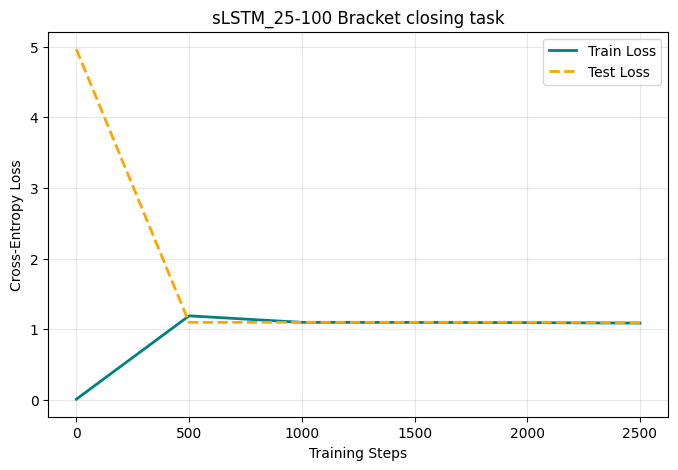

STEP: 2500 | TRAIN LOSS: 1.0876 | TEST LOSS: 1.0942


  0%|          | 0/10 [00:00<?, ?it/s]

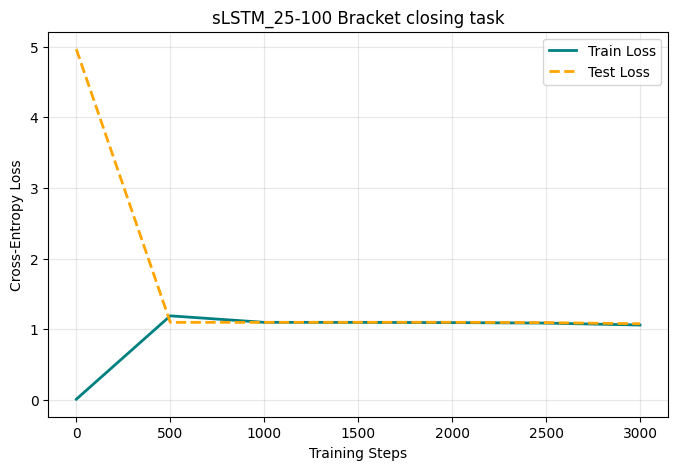

STEP: 3000 | TRAIN LOSS: 1.0602 | TEST LOSS: 1.0785


  0%|          | 0/10 [00:00<?, ?it/s]

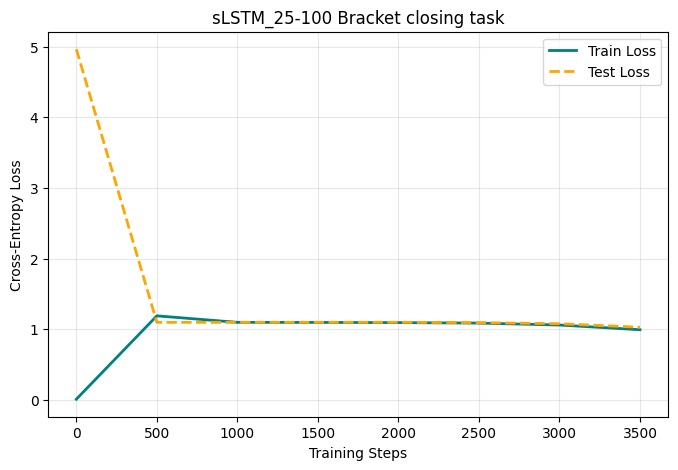

STEP: 3500 | TRAIN LOSS: 0.9938 | TEST LOSS: 1.0289


  0%|          | 0/10 [00:00<?, ?it/s]

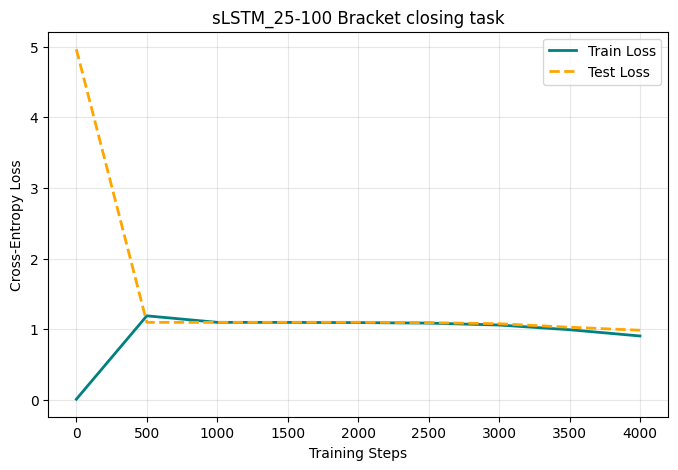

STEP: 4000 | TRAIN LOSS: 0.9051 | TEST LOSS: 0.9865


  0%|          | 0/10 [00:00<?, ?it/s]

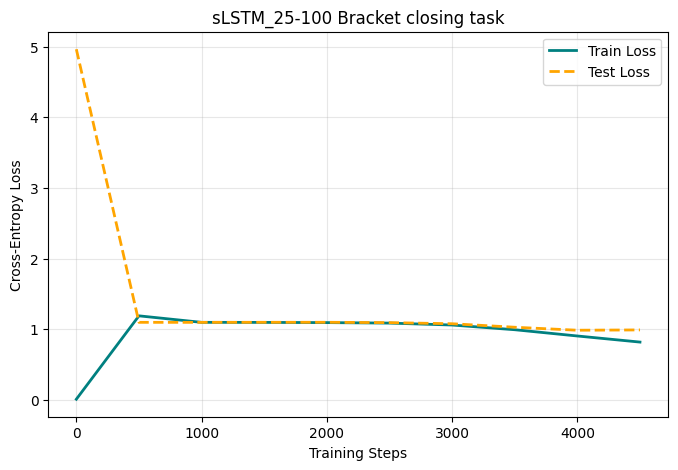

STEP: 4500 | TRAIN LOSS: 0.8188 | TEST LOSS: 0.9908


  0%|          | 0/10 [00:00<?, ?it/s]

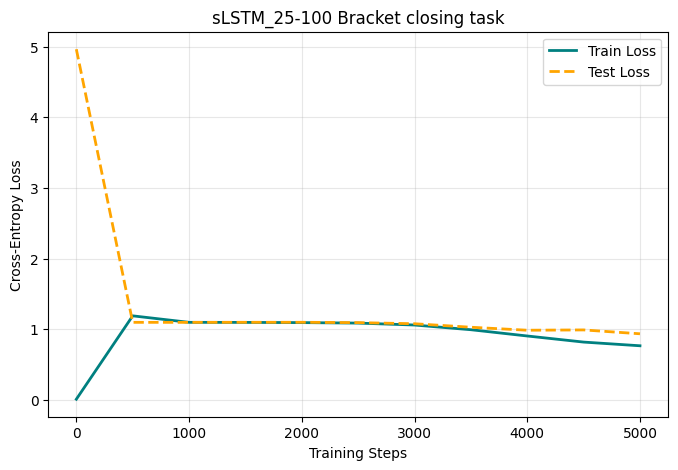

STEP: 5000 | TRAIN LOSS: 0.7665 | TEST LOSS: 0.9363


  0%|          | 0/10 [00:00<?, ?it/s]

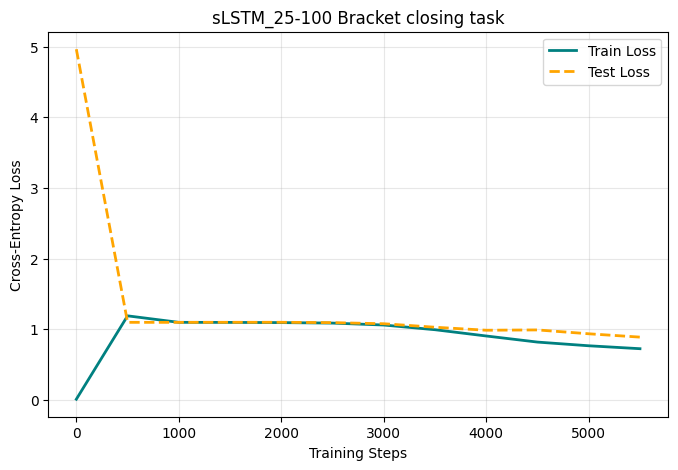

STEP: 5500 | TRAIN LOSS: 0.7251 | TEST LOSS: 0.8890


  0%|          | 0/10 [00:00<?, ?it/s]

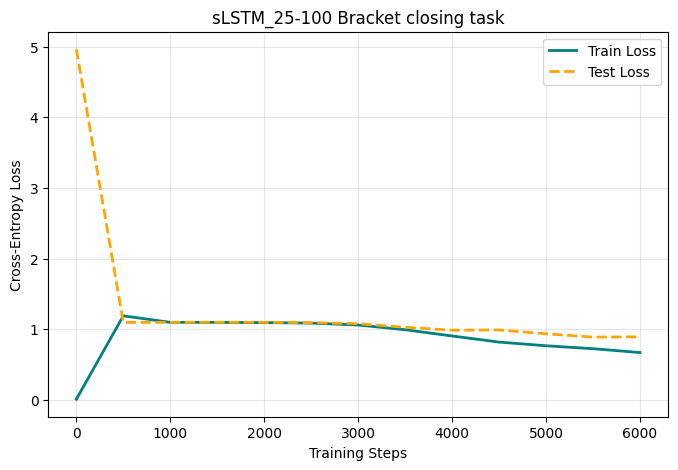

STEP: 6000 | TRAIN LOSS: 0.6706 | TEST LOSS: 0.8932


  0%|          | 0/10 [00:00<?, ?it/s]

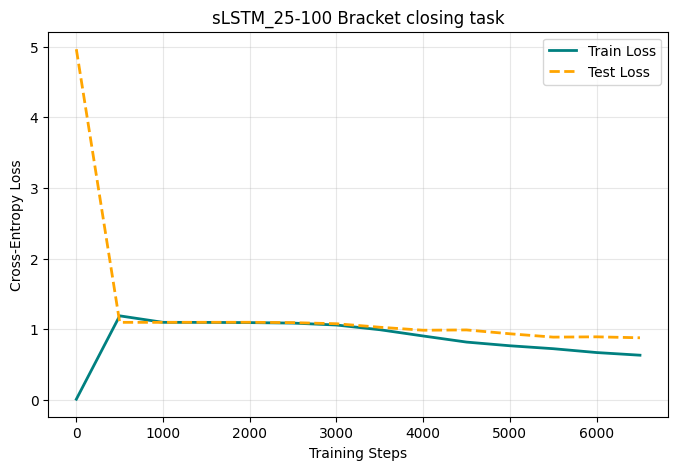

STEP: 6500 | TRAIN LOSS: 0.6331 | TEST LOSS: 0.8797


  0%|          | 0/10 [00:00<?, ?it/s]

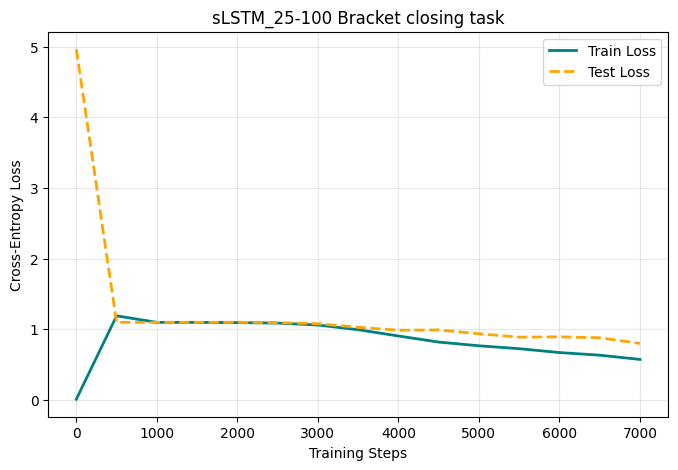

STEP: 7000 | TRAIN LOSS: 0.5733 | TEST LOSS: 0.7998


In [5]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=sLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

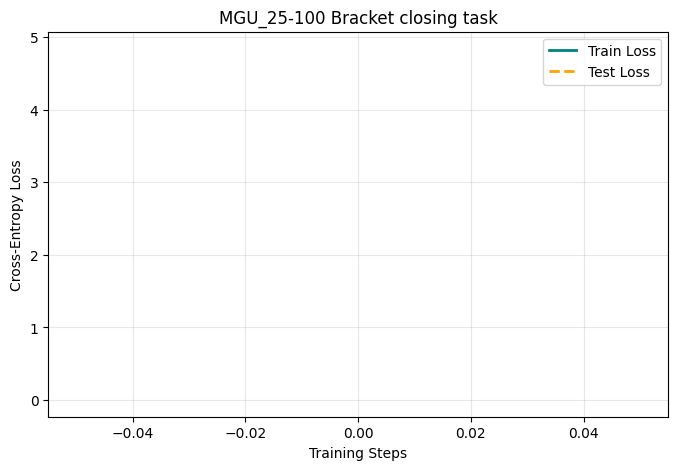

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.8340


  0%|          | 0/10 [00:00<?, ?it/s]

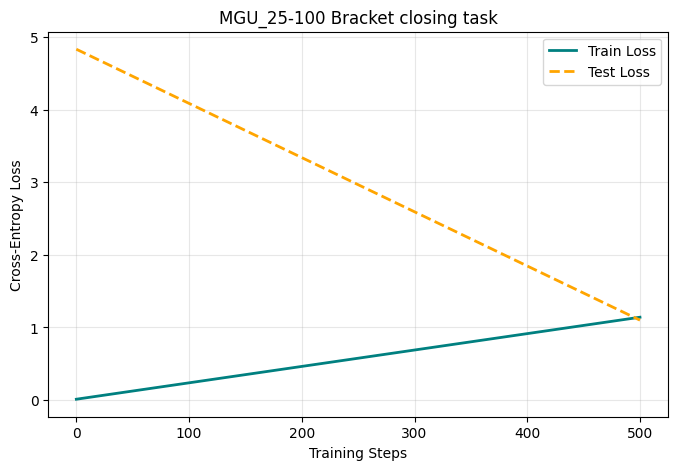

STEP: 500 | TRAIN LOSS: 1.1402 | TEST LOSS: 1.0995


  0%|          | 0/10 [00:00<?, ?it/s]

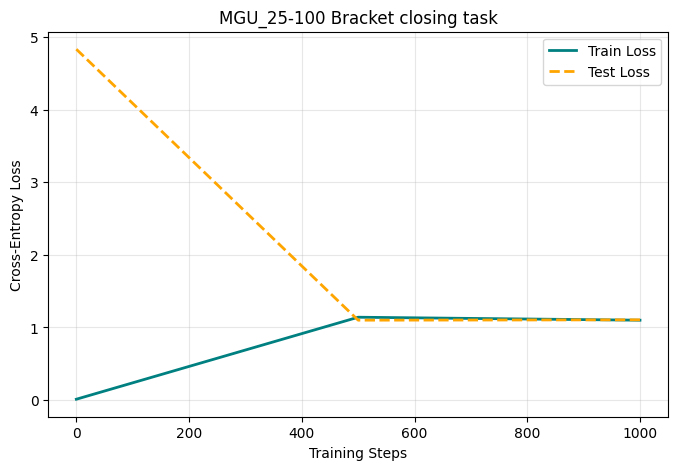

STEP: 1000 | TRAIN LOSS: 1.0991 | TEST LOSS: 1.1045


  0%|          | 0/10 [00:00<?, ?it/s]

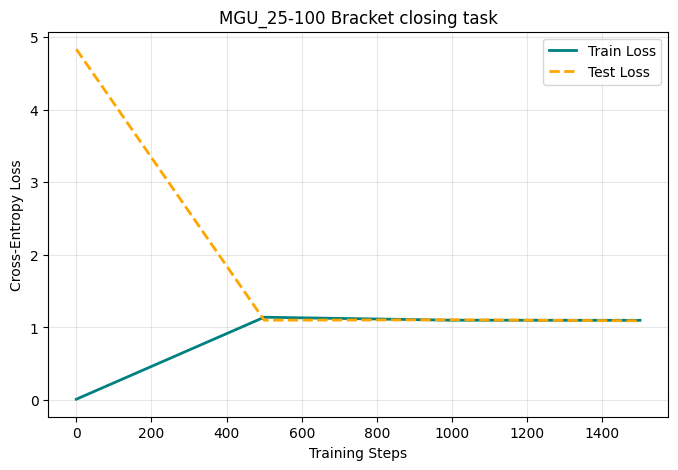

STEP: 1500 | TRAIN LOSS: 1.0975 | TEST LOSS: 1.0912


  0%|          | 0/10 [00:00<?, ?it/s]

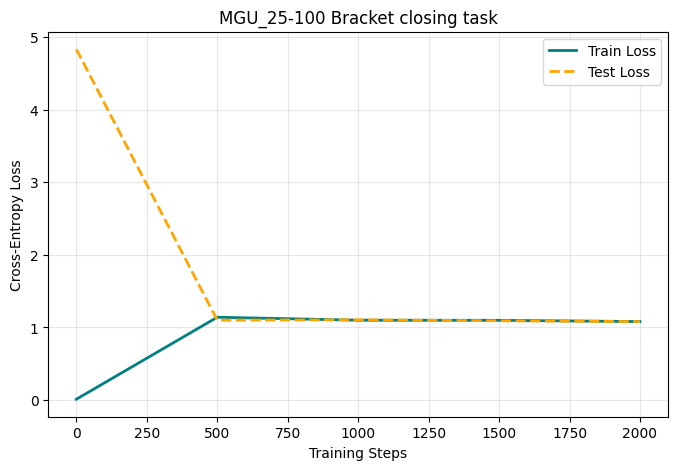

STEP: 2000 | TRAIN LOSS: 1.0803 | TEST LOSS: 1.0798


  0%|          | 0/10 [00:00<?, ?it/s]

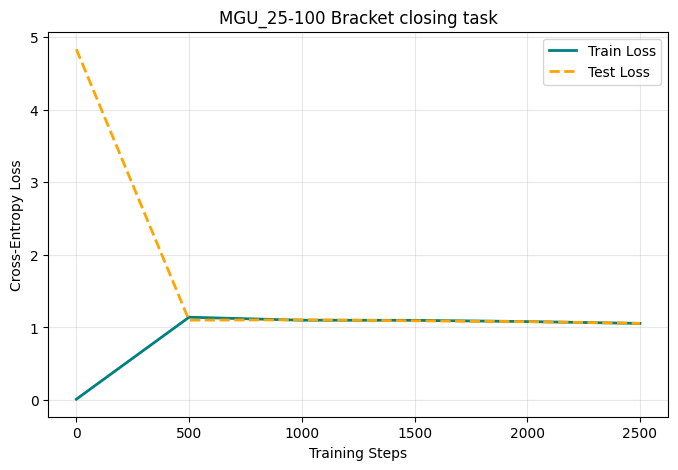

STEP: 2500 | TRAIN LOSS: 1.0548 | TEST LOSS: 1.0561


  0%|          | 0/10 [00:00<?, ?it/s]

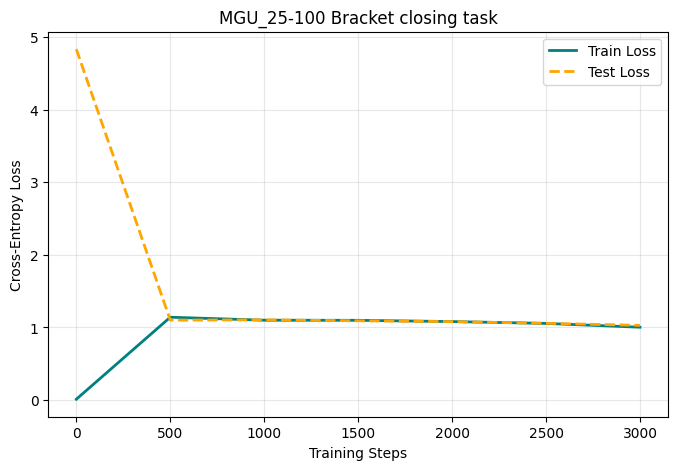

STEP: 3000 | TRAIN LOSS: 1.0024 | TEST LOSS: 1.0281


  0%|          | 0/10 [00:00<?, ?it/s]

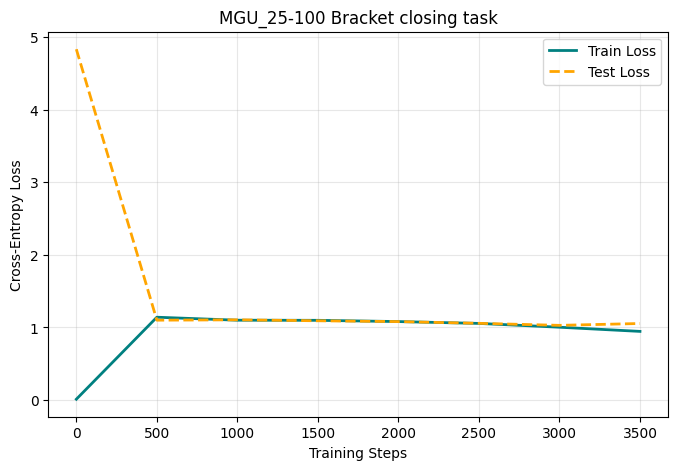

STEP: 3500 | TRAIN LOSS: 0.9449 | TEST LOSS: 1.0536


  0%|          | 0/10 [00:00<?, ?it/s]

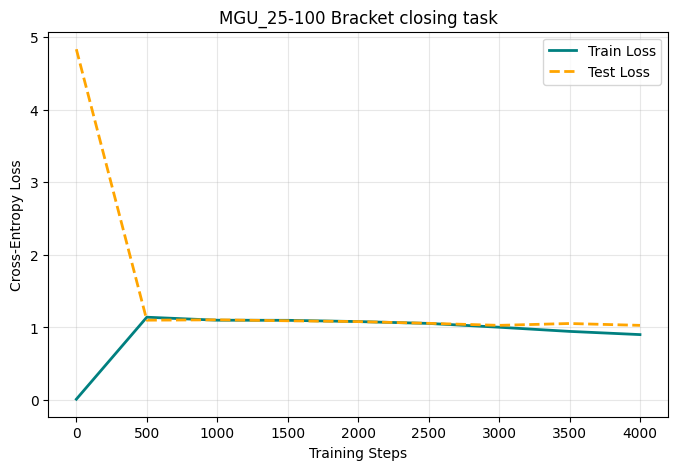

STEP: 4000 | TRAIN LOSS: 0.9007 | TEST LOSS: 1.0280


  0%|          | 0/10 [00:00<?, ?it/s]

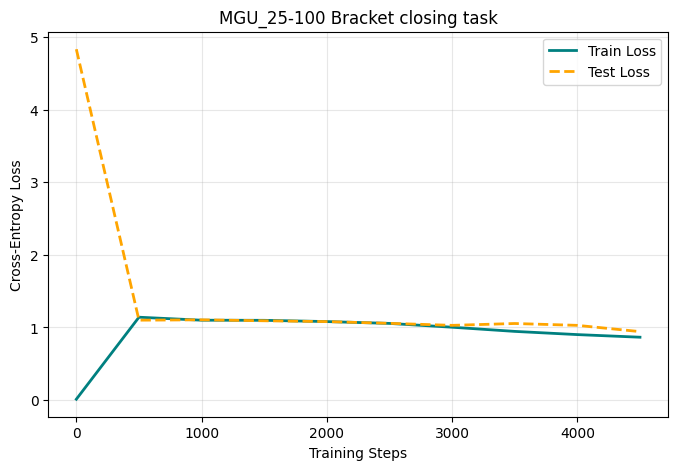

STEP: 4500 | TRAIN LOSS: 0.8647 | TEST LOSS: 0.9419


  0%|          | 0/10 [00:00<?, ?it/s]

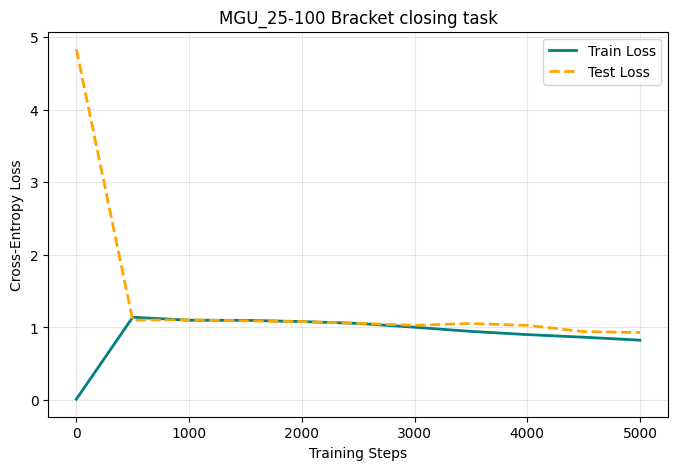

STEP: 5000 | TRAIN LOSS: 0.8241 | TEST LOSS: 0.9291


  0%|          | 0/10 [00:00<?, ?it/s]

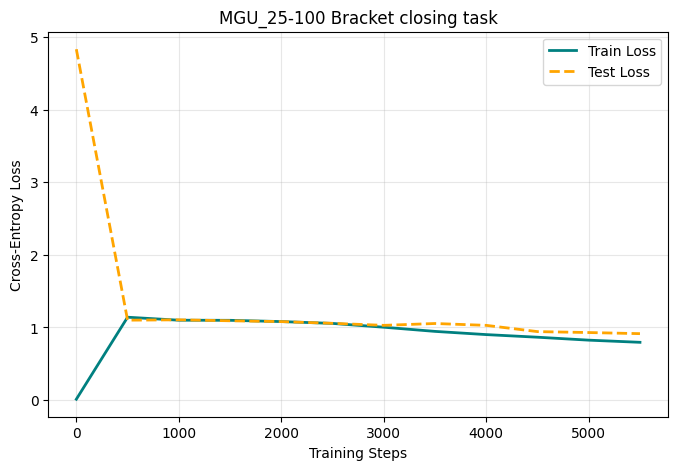

STEP: 5500 | TRAIN LOSS: 0.7944 | TEST LOSS: 0.9137


  0%|          | 0/10 [00:00<?, ?it/s]

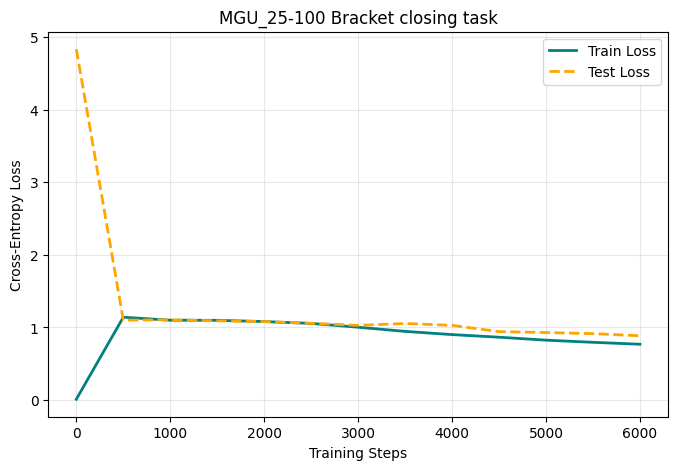

STEP: 6000 | TRAIN LOSS: 0.7677 | TEST LOSS: 0.8848


  0%|          | 0/10 [00:00<?, ?it/s]

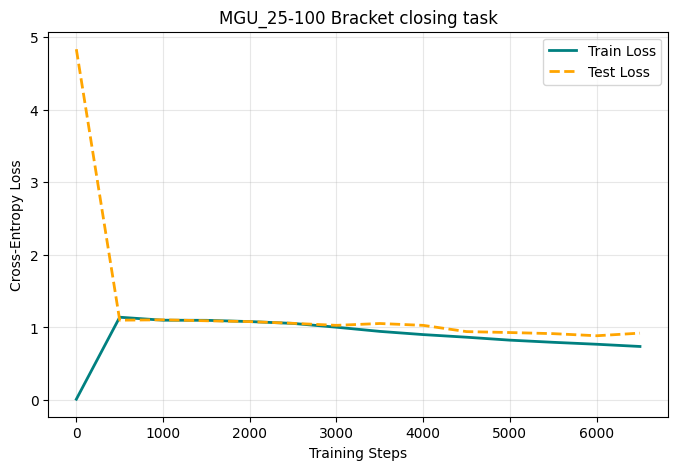

STEP: 6500 | TRAIN LOSS: 0.7370 | TEST LOSS: 0.9210


  0%|          | 0/10 [00:00<?, ?it/s]

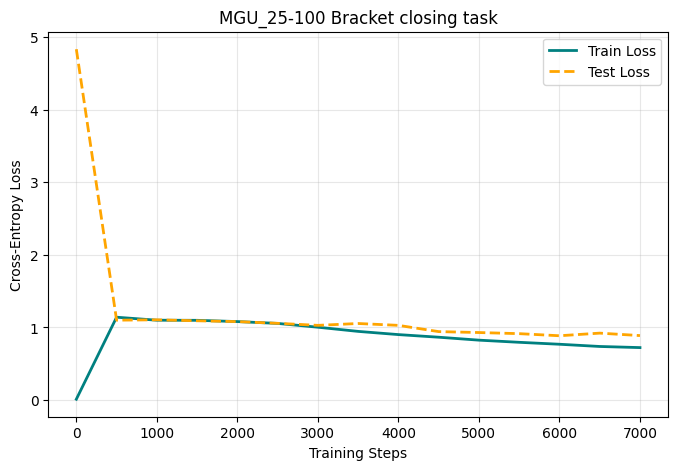

STEP: 7000 | TRAIN LOSS: 0.7216 | TEST LOSS: 0.8872


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=MGU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_MGU, 
                 test_break=500, 
                 model_name="MGU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

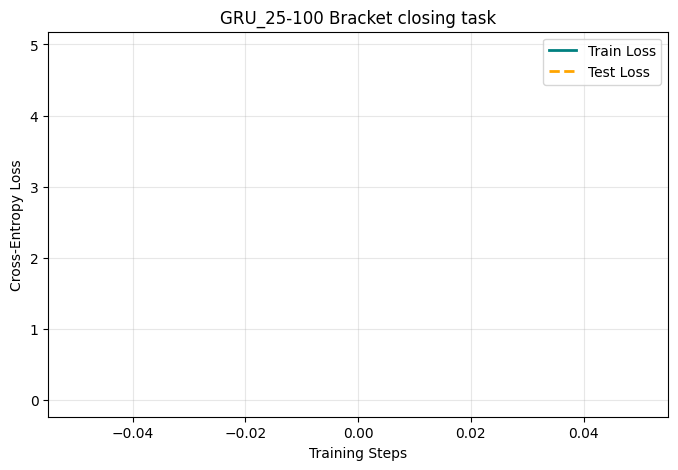

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9332


  0%|          | 0/10 [00:00<?, ?it/s]

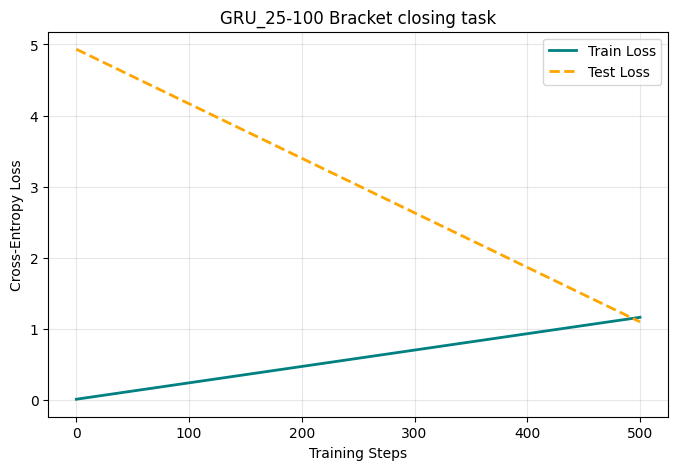

STEP: 500 | TRAIN LOSS: 1.1622 | TEST LOSS: 1.0982


  0%|          | 0/10 [00:00<?, ?it/s]

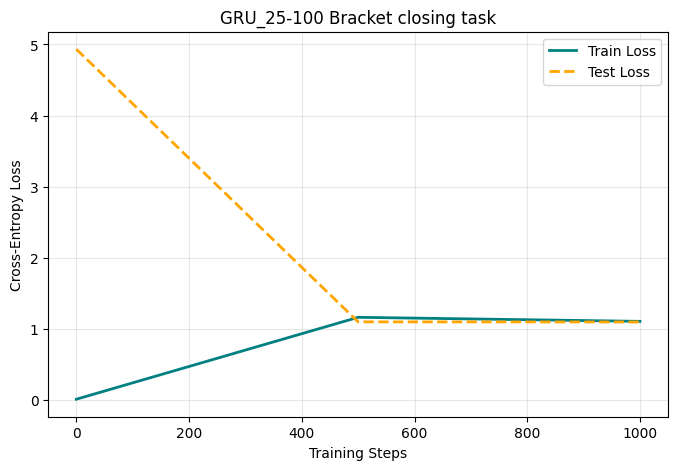

STEP: 1000 | TRAIN LOSS: 1.1051 | TEST LOSS: 1.0966


  0%|          | 0/10 [00:00<?, ?it/s]

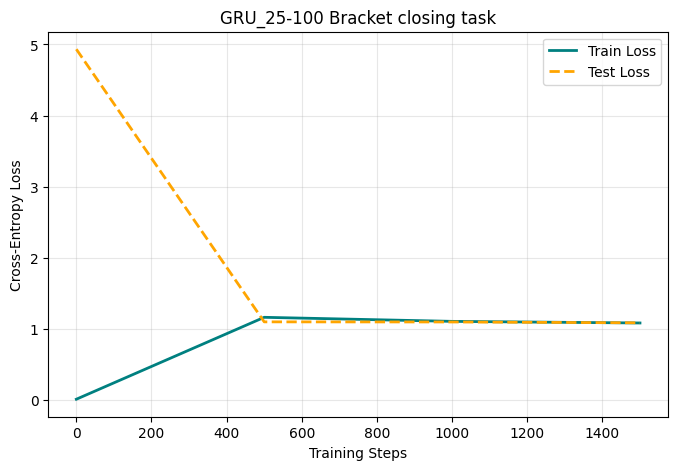

STEP: 1500 | TRAIN LOSS: 1.0824 | TEST LOSS: 1.0848


  0%|          | 0/10 [00:00<?, ?it/s]

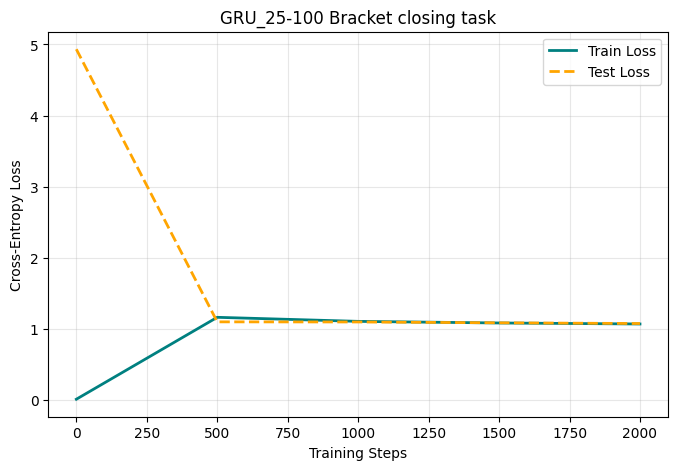

STEP: 2000 | TRAIN LOSS: 1.0683 | TEST LOSS: 1.0748


  0%|          | 0/10 [00:00<?, ?it/s]

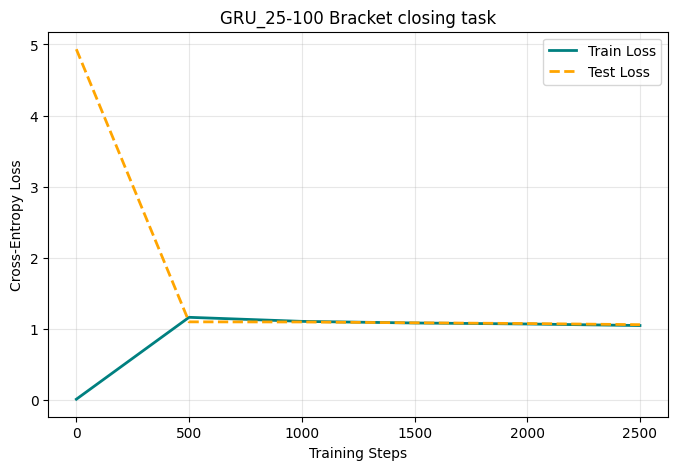

STEP: 2500 | TRAIN LOSS: 1.0466 | TEST LOSS: 1.0586


  0%|          | 0/10 [00:00<?, ?it/s]

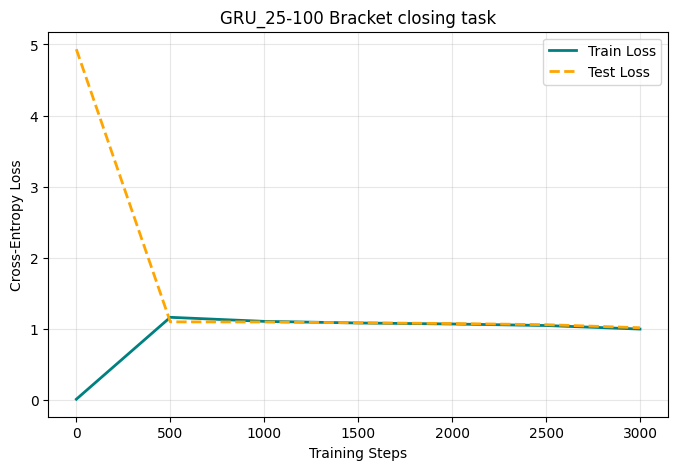

STEP: 3000 | TRAIN LOSS: 0.9968 | TEST LOSS: 1.0156


  0%|          | 0/10 [00:00<?, ?it/s]

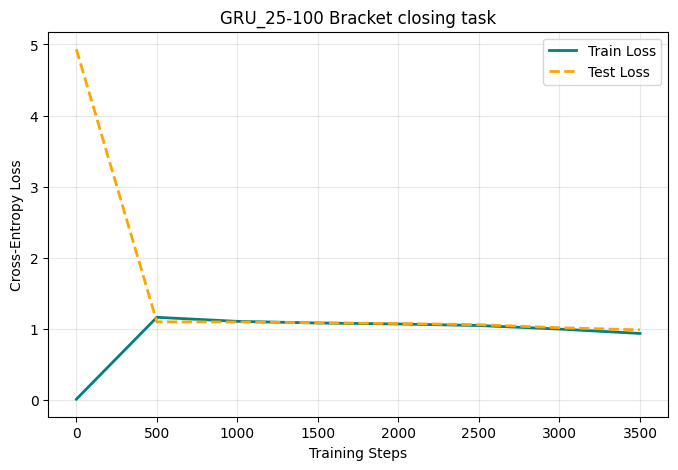

STEP: 3500 | TRAIN LOSS: 0.9352 | TEST LOSS: 0.9862


  0%|          | 0/10 [00:00<?, ?it/s]

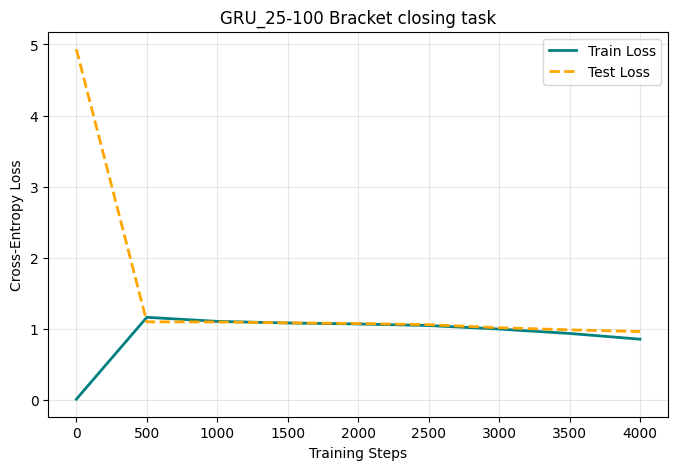

STEP: 4000 | TRAIN LOSS: 0.8544 | TEST LOSS: 0.9621


  0%|          | 0/10 [00:00<?, ?it/s]

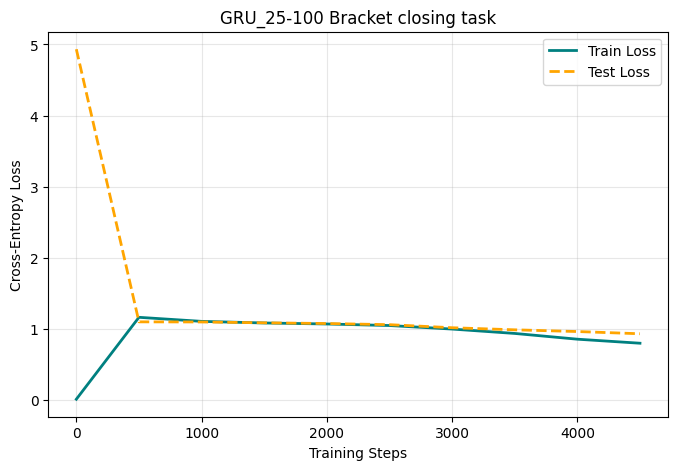

STEP: 4500 | TRAIN LOSS: 0.7977 | TEST LOSS: 0.9308


  0%|          | 0/10 [00:00<?, ?it/s]

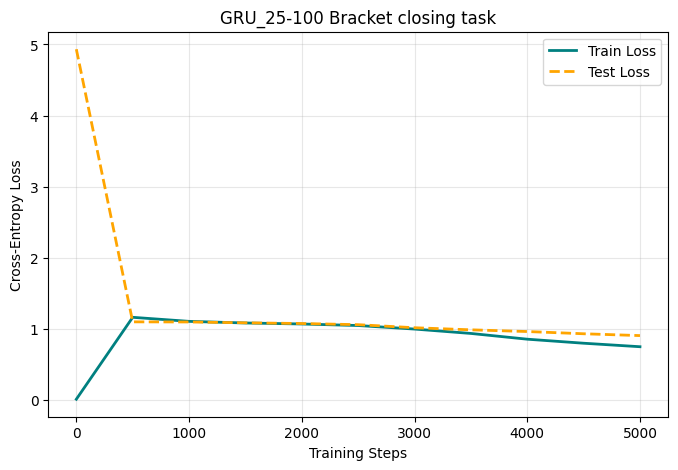

STEP: 5000 | TRAIN LOSS: 0.7484 | TEST LOSS: 0.9050


  0%|          | 0/10 [00:00<?, ?it/s]

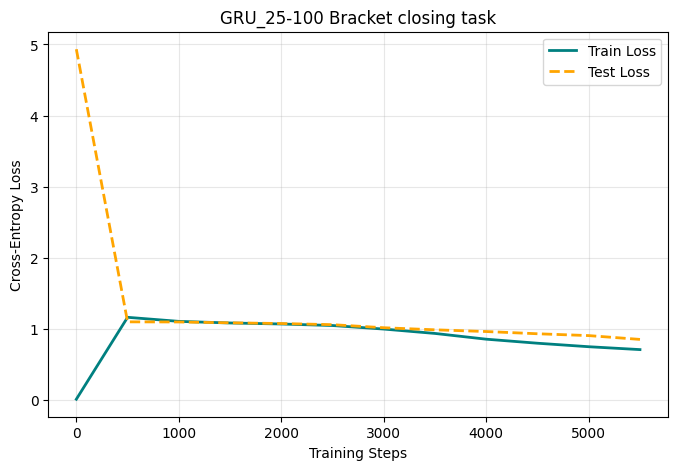

STEP: 5500 | TRAIN LOSS: 0.7080 | TEST LOSS: 0.8513


  0%|          | 0/10 [00:00<?, ?it/s]

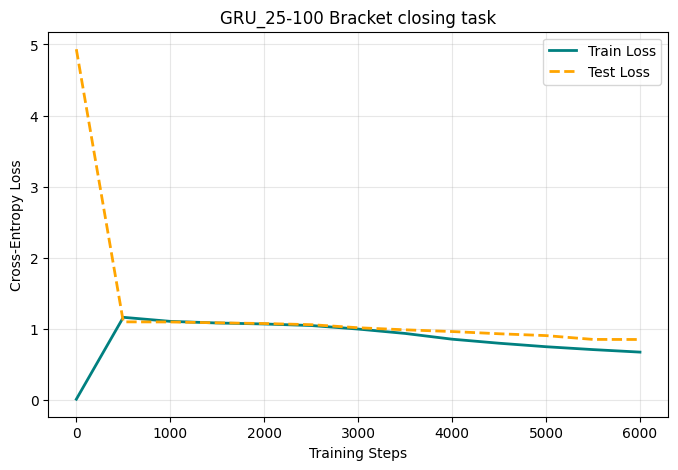

STEP: 6000 | TRAIN LOSS: 0.6727 | TEST LOSS: 0.8502


  0%|          | 0/10 [00:00<?, ?it/s]

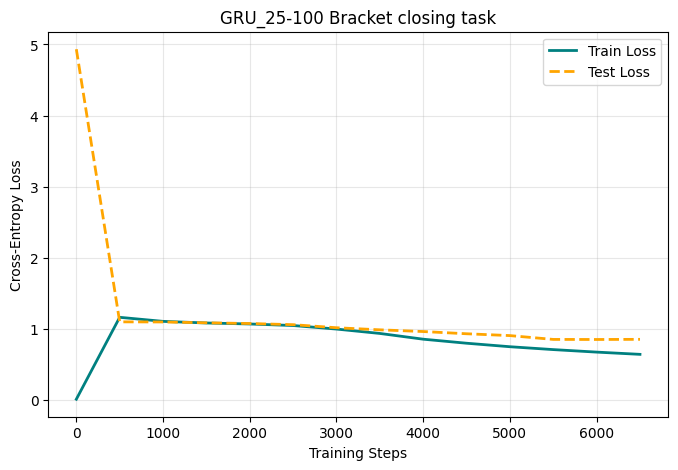

STEP: 6500 | TRAIN LOSS: 0.6412 | TEST LOSS: 0.8523


  0%|          | 0/10 [00:00<?, ?it/s]

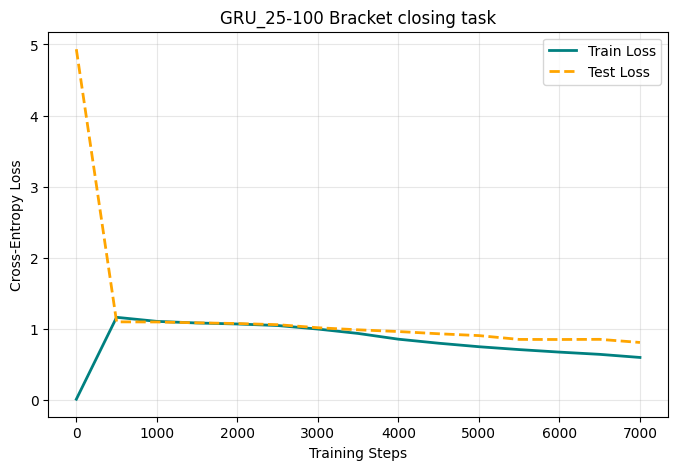

STEP: 7000 | TRAIN LOSS: 0.5974 | TEST LOSS: 0.8083


In [7]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=GRU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_GRU, 
                 test_break=500, 
                 model_name="GRU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

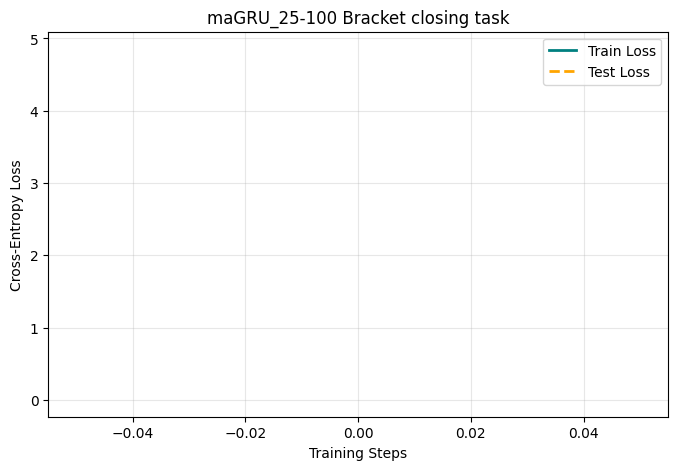

STEP: 0 | TRAIN LOSS: 0.0099 | TEST LOSS: 4.8504


  0%|          | 0/10 [00:00<?, ?it/s]

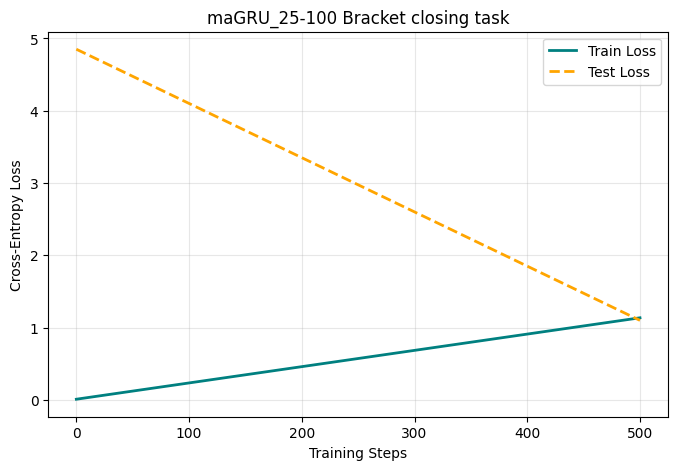

STEP: 500 | TRAIN LOSS: 1.1360 | TEST LOSS: 1.1003


  0%|          | 0/10 [00:00<?, ?it/s]

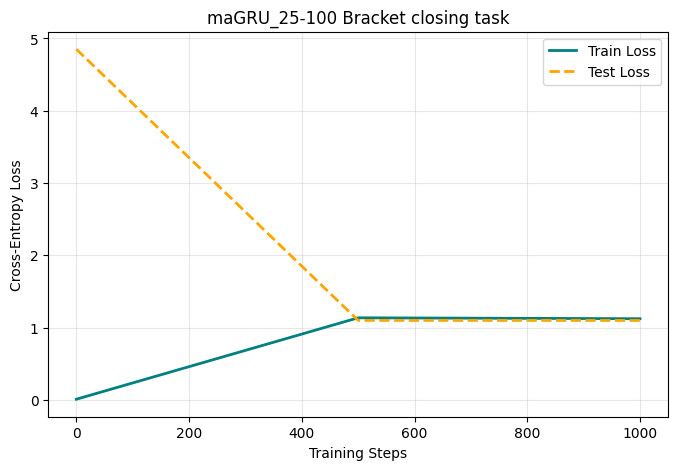

STEP: 1000 | TRAIN LOSS: 1.1233 | TEST LOSS: 1.0993


  0%|          | 0/10 [00:00<?, ?it/s]

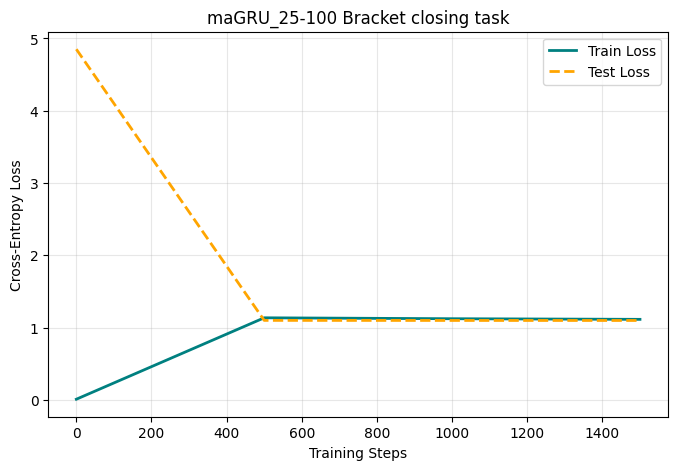

STEP: 1500 | TRAIN LOSS: 1.1146 | TEST LOSS: 1.0989


  0%|          | 0/10 [00:00<?, ?it/s]

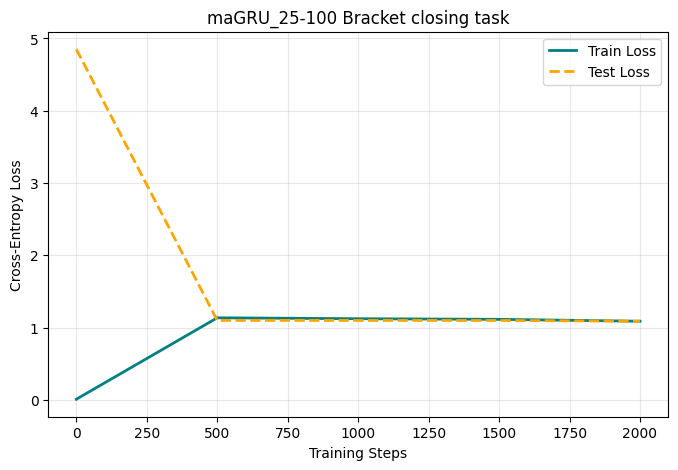

STEP: 2000 | TRAIN LOSS: 1.0885 | TEST LOSS: 1.0899


  0%|          | 0/10 [00:00<?, ?it/s]

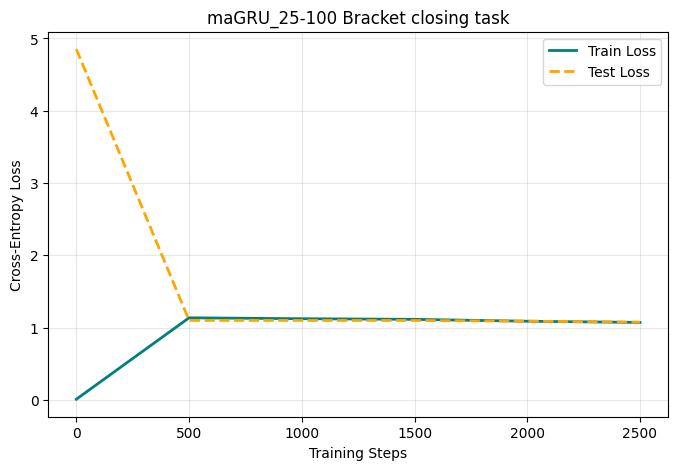

STEP: 2500 | TRAIN LOSS: 1.0718 | TEST LOSS: 1.0755


  0%|          | 0/10 [00:00<?, ?it/s]

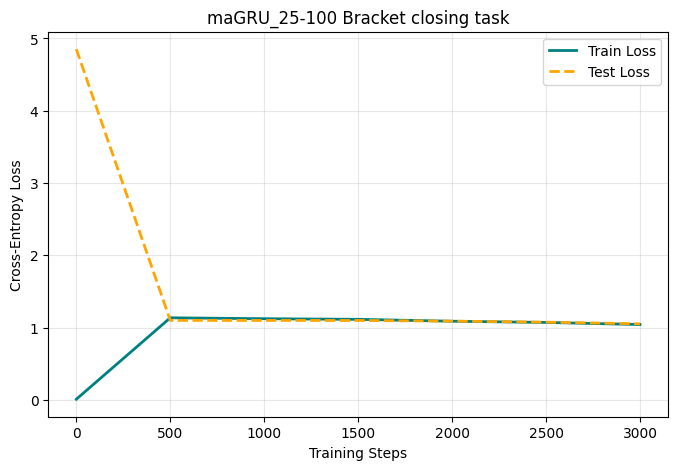

STEP: 3000 | TRAIN LOSS: 1.0427 | TEST LOSS: 1.0529


  0%|          | 0/10 [00:00<?, ?it/s]

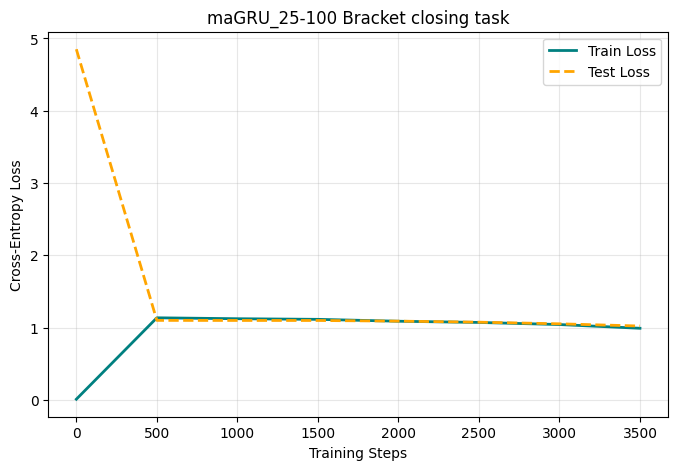

STEP: 3500 | TRAIN LOSS: 0.9912 | TEST LOSS: 1.0222


  0%|          | 0/10 [00:00<?, ?it/s]

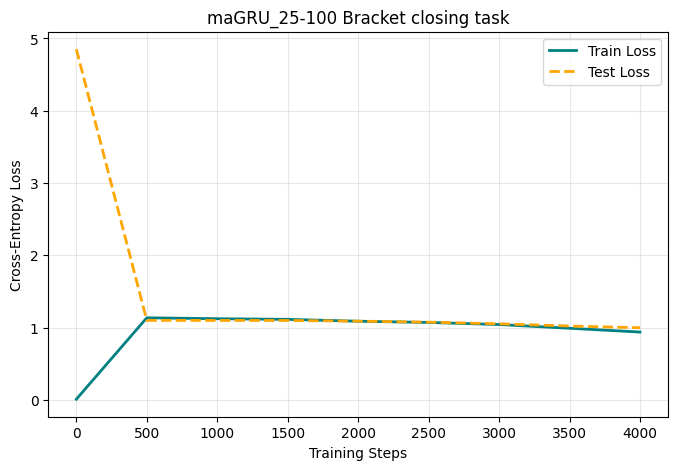

STEP: 4000 | TRAIN LOSS: 0.9389 | TEST LOSS: 0.9984


  0%|          | 0/10 [00:00<?, ?it/s]

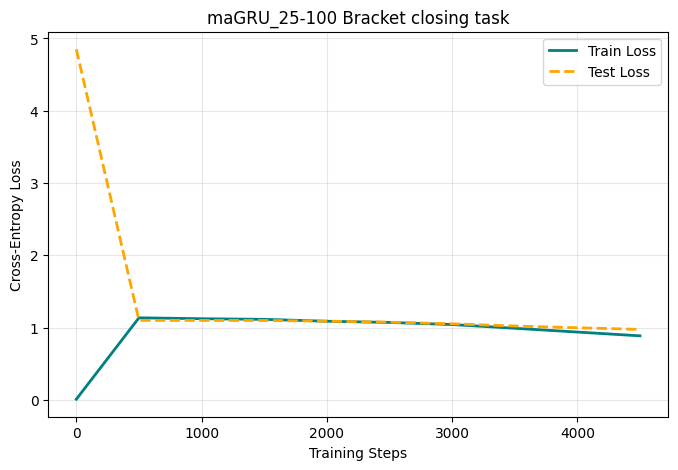

STEP: 4500 | TRAIN LOSS: 0.8864 | TEST LOSS: 0.9752


  0%|          | 0/10 [00:00<?, ?it/s]

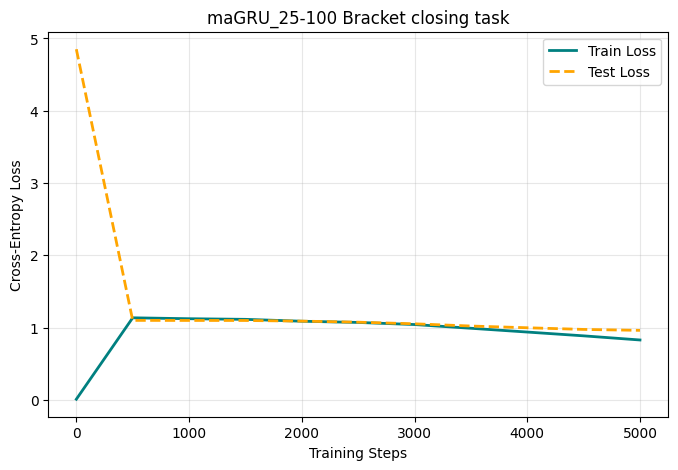

STEP: 5000 | TRAIN LOSS: 0.8292 | TEST LOSS: 0.9623


  0%|          | 0/10 [00:00<?, ?it/s]

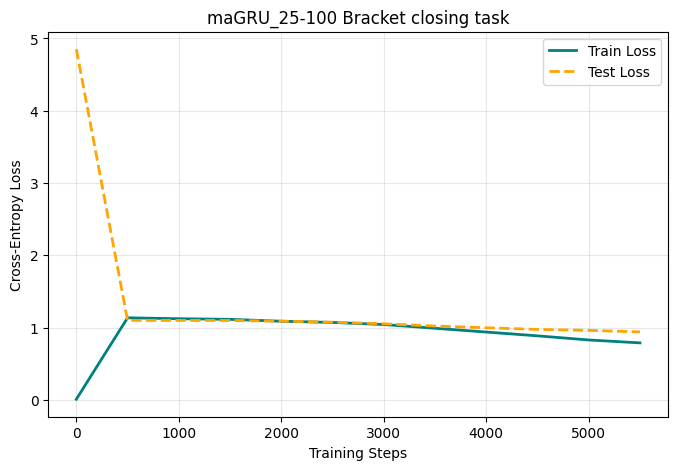

STEP: 5500 | TRAIN LOSS: 0.7891 | TEST LOSS: 0.9412


  0%|          | 0/10 [00:00<?, ?it/s]

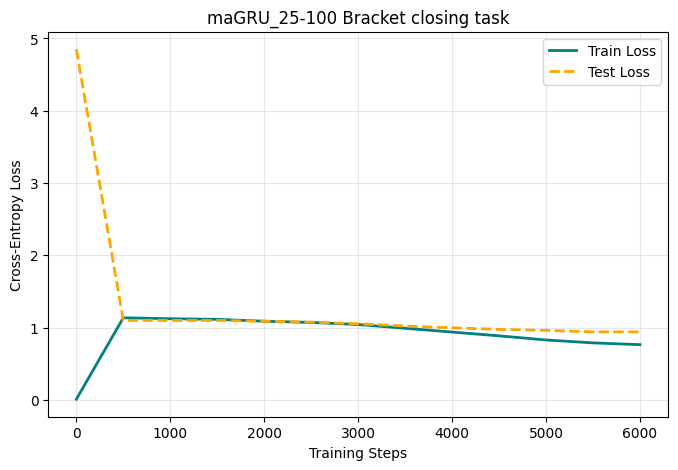

STEP: 6000 | TRAIN LOSS: 0.7646 | TEST LOSS: 0.9409


  0%|          | 0/10 [00:00<?, ?it/s]

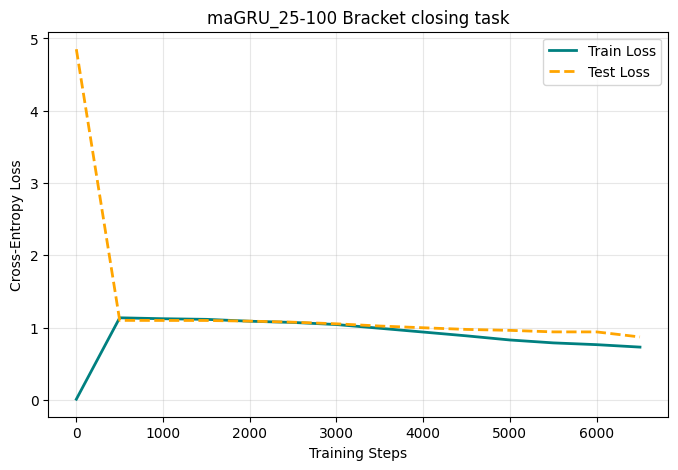

STEP: 6500 | TRAIN LOSS: 0.7307 | TEST LOSS: 0.8708


  0%|          | 0/10 [00:00<?, ?it/s]

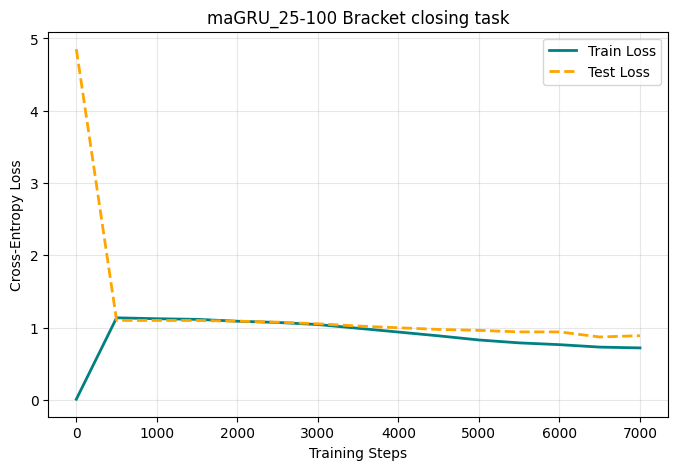

STEP: 7000 | TRAIN LOSS: 0.7195 | TEST LOSS: 0.8889


In [8]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=maGRU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

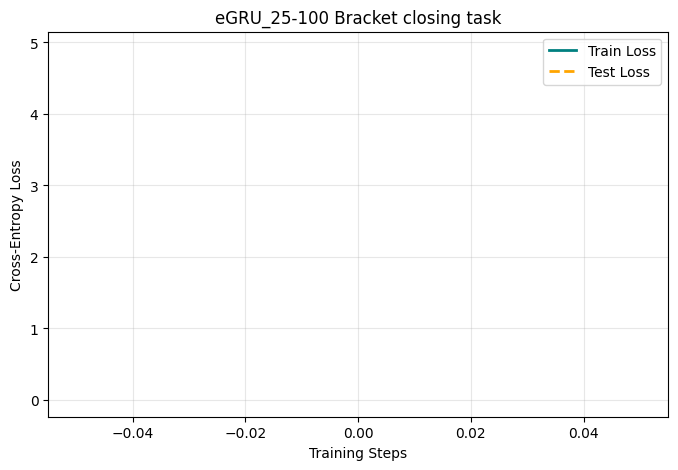

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 4.9053


  0%|          | 0/10 [00:00<?, ?it/s]

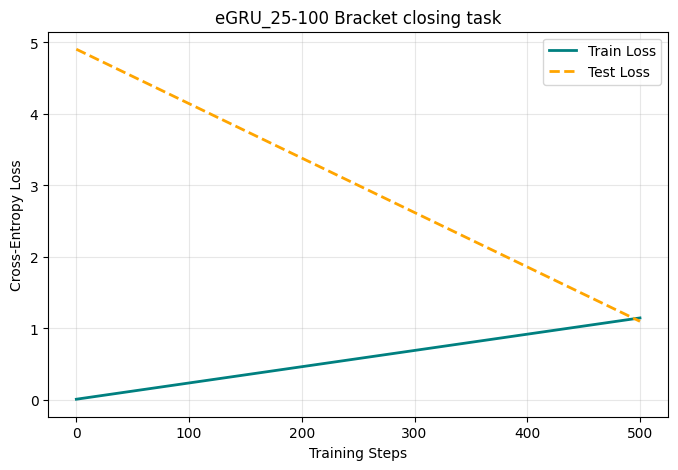

STEP: 500 | TRAIN LOSS: 1.1470 | TEST LOSS: 1.0993


  0%|          | 0/10 [00:00<?, ?it/s]

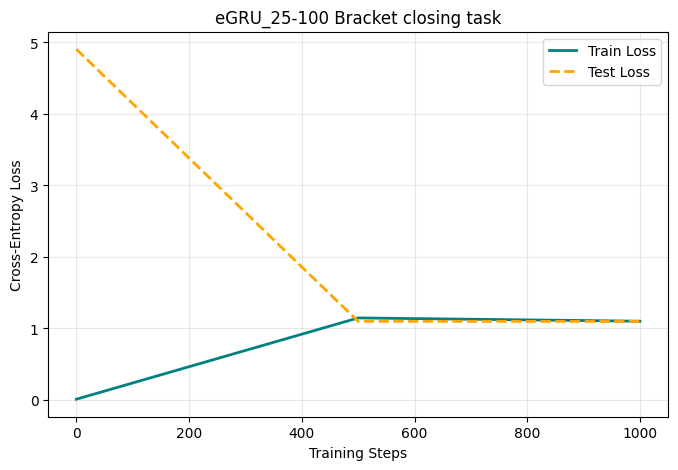

STEP: 1000 | TRAIN LOSS: 1.1012 | TEST LOSS: 1.0982


  0%|          | 0/10 [00:00<?, ?it/s]

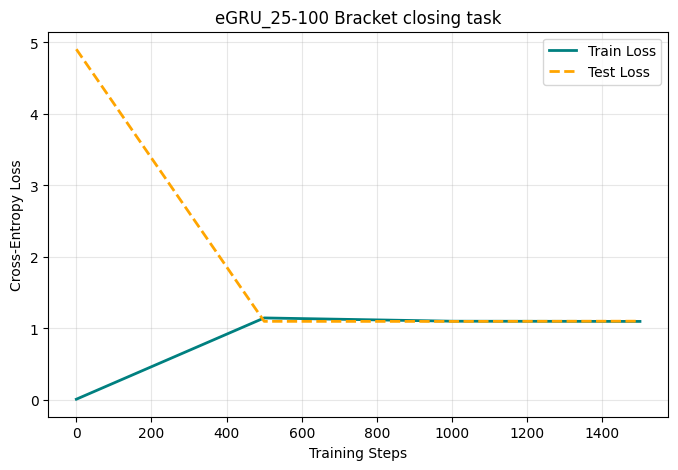

STEP: 1500 | TRAIN LOSS: 1.0982 | TEST LOSS: 1.1017


  0%|          | 0/10 [00:00<?, ?it/s]

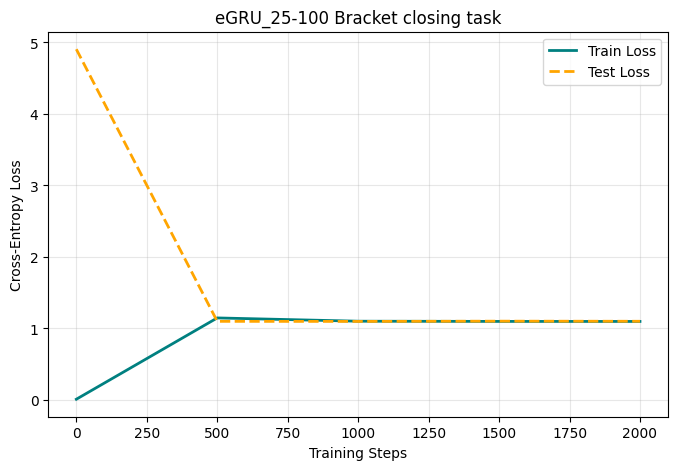

STEP: 2000 | TRAIN LOSS: 1.0978 | TEST LOSS: 1.1002


  0%|          | 0/10 [00:00<?, ?it/s]

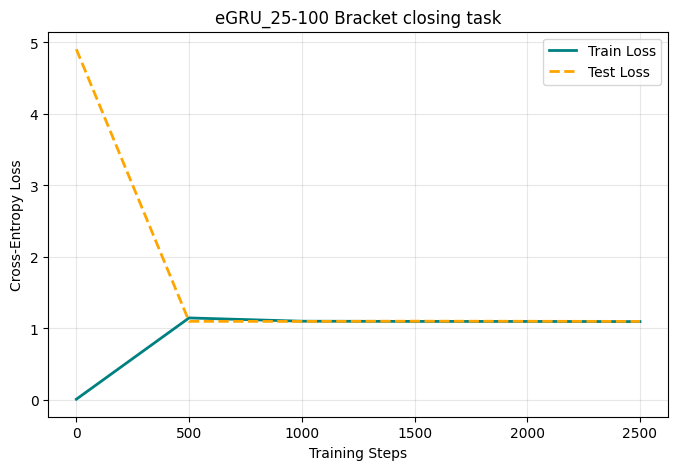

STEP: 2500 | TRAIN LOSS: 1.0959 | TEST LOSS: 1.0982


  0%|          | 0/10 [00:00<?, ?it/s]

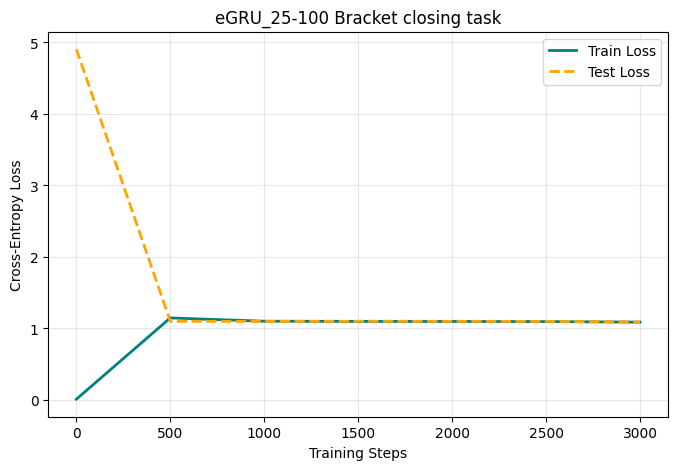

STEP: 3000 | TRAIN LOSS: 1.0885 | TEST LOSS: 1.0910


  0%|          | 0/10 [00:00<?, ?it/s]

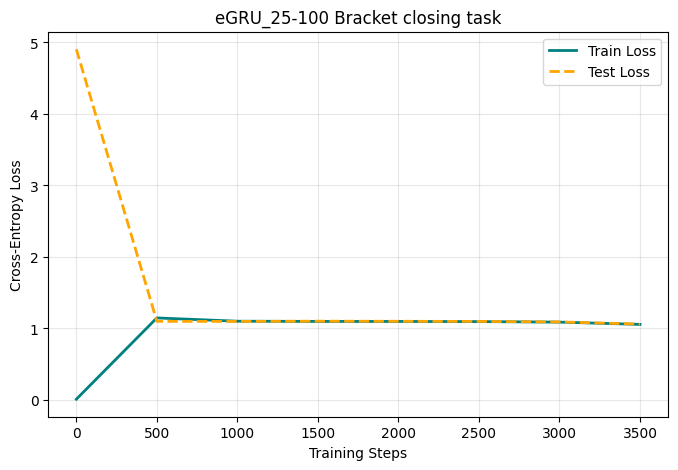

STEP: 3500 | TRAIN LOSS: 1.0565 | TEST LOSS: 1.0609


  0%|          | 0/10 [00:00<?, ?it/s]

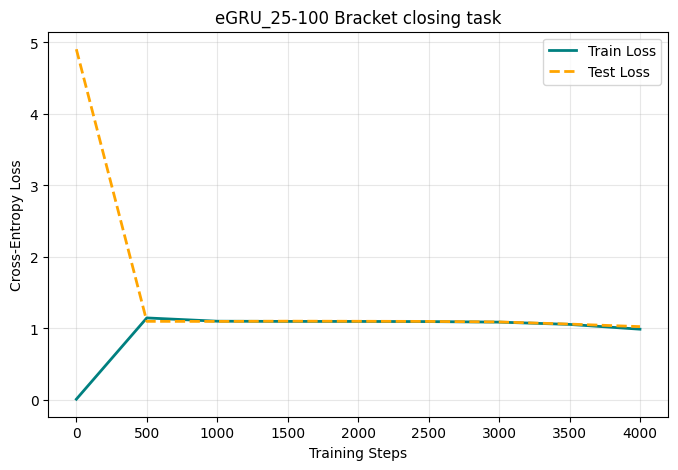

STEP: 4000 | TRAIN LOSS: 0.9896 | TEST LOSS: 1.0254


  0%|          | 0/10 [00:00<?, ?it/s]

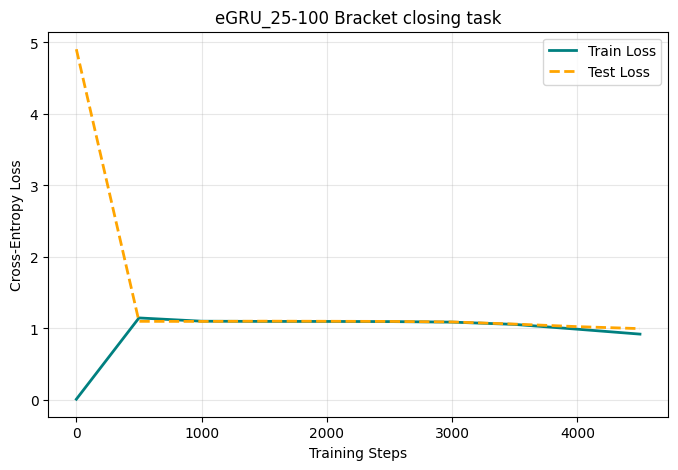

STEP: 4500 | TRAIN LOSS: 0.9206 | TEST LOSS: 0.9976


  0%|          | 0/10 [00:00<?, ?it/s]

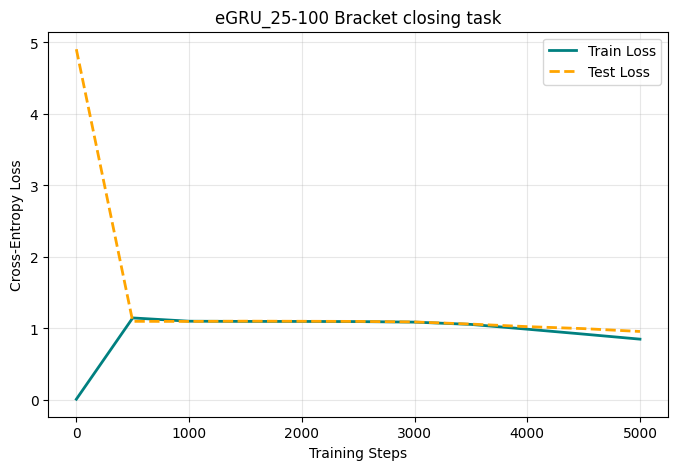

STEP: 5000 | TRAIN LOSS: 0.8502 | TEST LOSS: 0.9575


  0%|          | 0/10 [00:00<?, ?it/s]

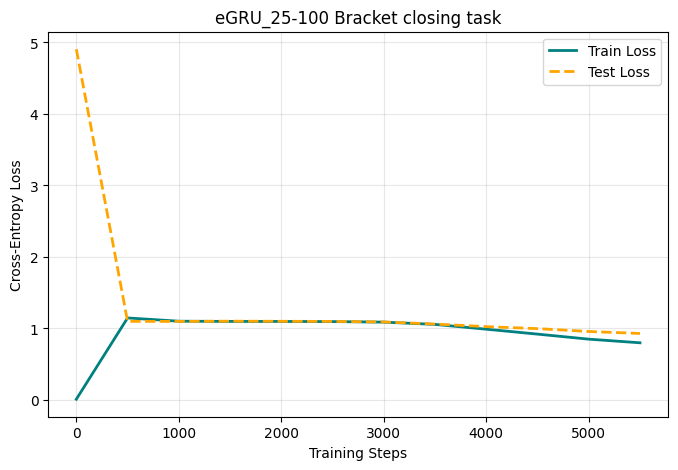

STEP: 5500 | TRAIN LOSS: 0.7992 | TEST LOSS: 0.9297


  0%|          | 0/10 [00:00<?, ?it/s]

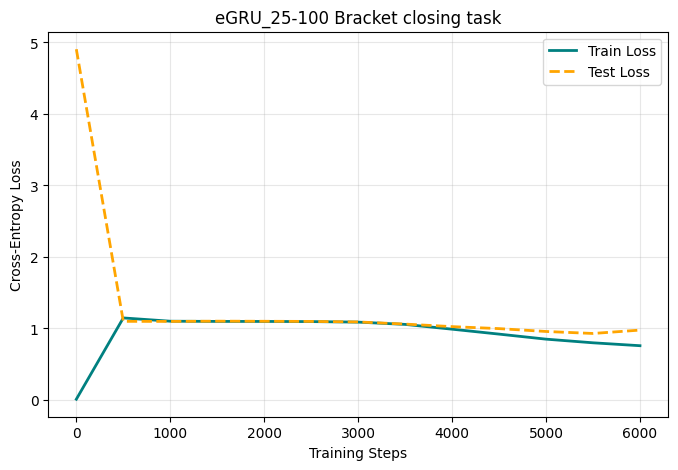

STEP: 6000 | TRAIN LOSS: 0.7586 | TEST LOSS: 0.9769


  0%|          | 0/10 [00:00<?, ?it/s]

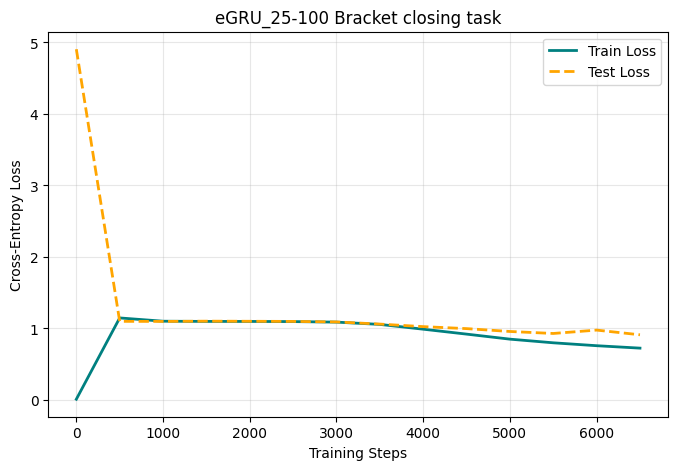

STEP: 6500 | TRAIN LOSS: 0.7247 | TEST LOSS: 0.9111


  0%|          | 0/10 [00:00<?, ?it/s]

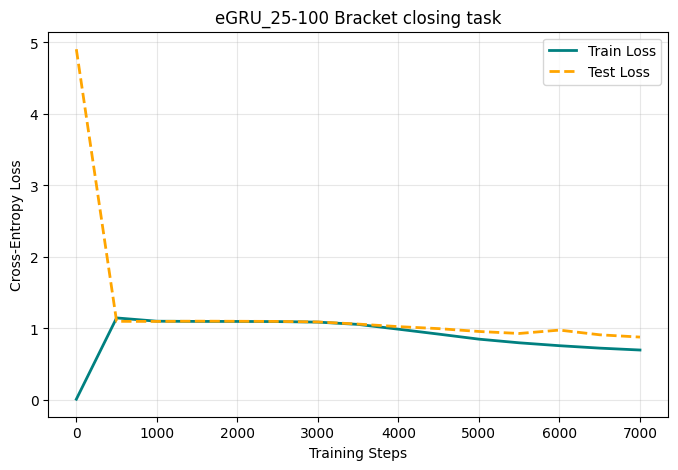

STEP: 7000 | TRAIN LOSS: 0.6982 | TEST LOSS: 0.8792


In [9]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=eGRU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

## Testing the models!

In [5]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [6]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

load_model("./models/ex4/mLSTM_25-100_ex4_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("./models/ex4/mLSTMLite_25-100_ex4_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("./models/ex4/sLSTM_25-100_ex4_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex4/MGU_25-100_ex4_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex4/maGRU_25-100_ex4_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex4/GRU_25-100_ex4_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex4/eGRU_25-100_ex4_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)


7001

In [10]:

ex1_mlstm_50   =  evaluate_ex4(mLSTM_model, bracket_values, teacher_forcing=False, buffer_size=15,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_100  =  evaluate_ex4(mLSTM_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_250  =  evaluate_ex4(mLSTM_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_500  =  evaluate_ex4(mLSTM_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_750  =  evaluate_ex4(mLSTM_model, bracket_values, teacher_forcing=False, buffer_size=100,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_1000 = evaluate_ex4(mLSTM_model,  bracket_values, teacher_forcing=False,  buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTM bracket closing difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM bracket closing difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM bracket closing difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM bracket closing difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM bracket closing difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM bracket closing difference at buffer_size=1000: ", ex1_mlstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTM bracket closing difference at buffer_size=50:  0.6092615841638924
mLSTM bracket closing difference at buffer_size=100:  0.6382796858796979
mLSTM bracket closing difference at buffer_size=250:  0.6539046864698429
mLSTM bracket closing difference at buffer_size=500:  0.6557797187625771
mLSTM bracket closing difference at buffer_size=750:  0.6598452831258869
mLSTM bracket closing difference at buffer_size=1000:  0.6636374079354919


In [11]:

ex1_mlstmlite_50   = evaluate_ex4(mLSTMLite_model, bracket_values, teacher_forcing=False, buffer_size=15,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_100  = evaluate_ex4(mLSTMLite_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_250  = evaluate_ex4(mLSTMLite_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_500  = evaluate_ex4(mLSTMLite_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_750  = evaluate_ex4(mLSTMLite_model, bracket_values, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_1000 = evaluate_ex4(mLSTMLite_model, bracket_values, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTMLite bracket closing difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite bracket closing difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite bracket closing difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite bracket closing difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite bracket closing difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite bracket closing difference at buffer_size=1000: ", ex1_mlstmlite_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTMLite bracket closing difference at buffer_size=50:  0.6146246230248178
mLSTMLite bracket closing difference at buffer_size=100:  0.6373885970304508
mLSTMLite bracket closing difference at buffer_size=250:  0.655068054057584
mLSTMLite bracket closing difference at buffer_size=500:  0.6577475371927318
mLSTMLite bracket closing difference at buffer_size=750:  0.6589046870127763
mLSTMLite bracket closing difference at buffer_size=1000:  0.6631609207332725


In [12]:

ex1_cgru_50 =   evaluate_ex4(GRU_model, bracket_values, teacher_forcing=False, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_100 =  evaluate_ex4(GRU_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_250 =  evaluate_ex4(GRU_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_500 =  evaluate_ex4(GRU_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_750 =  evaluate_ex4(GRU_model, bracket_values, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_1000 = evaluate_ex4(GRU_model, bracket_values, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("GRU bracket closing difference at buffer_size=50: ", ex1_cgru_50)
print("GRU bracket closing difference at buffer_size=100: ", ex1_cgru_100)
print("GRU bracket closing difference at buffer_size=250: ", ex1_cgru_250)
print("GRU bracket closing difference at buffer_size=500: ", ex1_cgru_500)
print("GRU bracket closing difference at buffer_size=750: ", ex1_cgru_750)
print("GRU bracket closing difference at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU bracket closing difference at buffer_size=50:  0.10913779492499215
GRU bracket closing difference at buffer_size=100:  0.28147276557318057
GRU bracket closing difference at buffer_size=250:  0.48473390051634
GRU bracket closing difference at buffer_size=500:  0.5504620618159228
GRU bracket closing difference at buffer_size=750:  0.5849535766214428
GRU bracket closing difference at buffer_size=1000:  0.6377190894419604


In [13]:
ex1_mgu_50 =   evaluate_ex4(MGU_model, bracket_values, teacher_forcing=False, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_100 =  evaluate_ex4(MGU_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_250 =  evaluate_ex4(MGU_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_500 =  evaluate_ex4(MGU_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_750 =  evaluate_ex4(MGU_model, bracket_values, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_1000 = evaluate_ex4(MGU_model, bracket_values, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("MGU bracket closing difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU bracket closing difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU bracket closing difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU bracket closing difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU bracket closing difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU bracket closing difference at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU bracket closing difference at buffer_size=50:  0.15261964669617095
MGU bracket closing difference at buffer_size=100:  0.32599009086590003
MGU bracket closing difference at buffer_size=250:  0.499486377038578
MGU bracket closing difference at buffer_size=500:  0.5641749306480484
MGU bracket closing difference at buffer_size=750:  0.5929207784114497
MGU bracket closing difference at buffer_size=1000:  0.6423304789137132


In [14]:
ex1_slstm_50 =   evaluate_ex4(sLSTM_model, bracket_values, teacher_forcing=False, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_100 =  evaluate_ex4(sLSTM_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_250 =  evaluate_ex4(sLSTM_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_500 =  evaluate_ex4(sLSTM_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_750 =  evaluate_ex4(sLSTM_model, bracket_values, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_1000 = evaluate_ex4(sLSTM_model, bracket_values, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("sLSTM bracket closing difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM bracket closing difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM bracket closing difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM bracket closing difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM bracket closing difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM bracket closing difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM bracket closing difference at buffer_size=50:  0.38446784314542715
sLSTM bracket closing difference at buffer_size=100:  0.2590098953483128
sLSTM bracket closing difference at buffer_size=250:  0.4637066730768374
sLSTM bracket closing difference at buffer_size=500:  0.5376444004549839
sLSTM bracket closing difference at buffer_size=750:  0.5720606310532825
sLSTM bracket closing difference at buffer_size=1000:  0.6313948312608322


In [15]:
ex1_magru_50 =   evaluate_ex4(maGRU_model, bracket_values, teacher_forcing=False, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_100 =  evaluate_ex4(maGRU_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_250 =  evaluate_ex4(maGRU_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_500 =  evaluate_ex4(maGRU_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_750 =  evaluate_ex4(maGRU_model, bracket_values, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_1000 = evaluate_ex4(maGRU_model, bracket_values, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("maGRU bracket closing difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU bracket closing difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU bracket closing difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU bracket closing difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU bracket closing difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU bracket closing difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU bracket closing difference at buffer_size=50:  0.19797855792659344
maGRU bracket closing difference at buffer_size=100:  0.3296039544119693
maGRU bracket closing difference at buffer_size=250:  0.4858725135869319
maGRU bracket closing difference at buffer_size=500:  0.5540924178491725
maGRU bracket closing difference at buffer_size=750:  0.5886850103293315
maGRU bracket closing difference at buffer_size=1000:  0.6421324545794195


In [7]:
ex1_eGRU_50 =   evaluate_ex4(eGRU_model, bracket_values, teacher_forcing=False, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_100 =  evaluate_ex4(eGRU_model, bracket_values, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_250 =  evaluate_ex4(eGRU_model, bracket_values, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_500 =  evaluate_ex4(eGRU_model, bracket_values, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_750 =  evaluate_ex4(eGRU_model, bracket_values, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex4(eGRU_model, bracket_values, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("eGRU bracket closing difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU bracket closing difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU bracket closing difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU bracket closing difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU bracket closing difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU bracket closing difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU bracket closing difference at buffer_size=50:  0.26099423710072395
eGRU bracket closing difference at buffer_size=100:  0.37758662647540026
eGRU bracket closing difference at buffer_size=250:  0.5026732571054213
eGRU bracket closing difference at buffer_size=500:  0.5542656920924045
eGRU bracket closing difference at buffer_size=750:  0.5830445395837917
eGRU bracket closing difference at buffer_size=1000:  0.6327822066769742


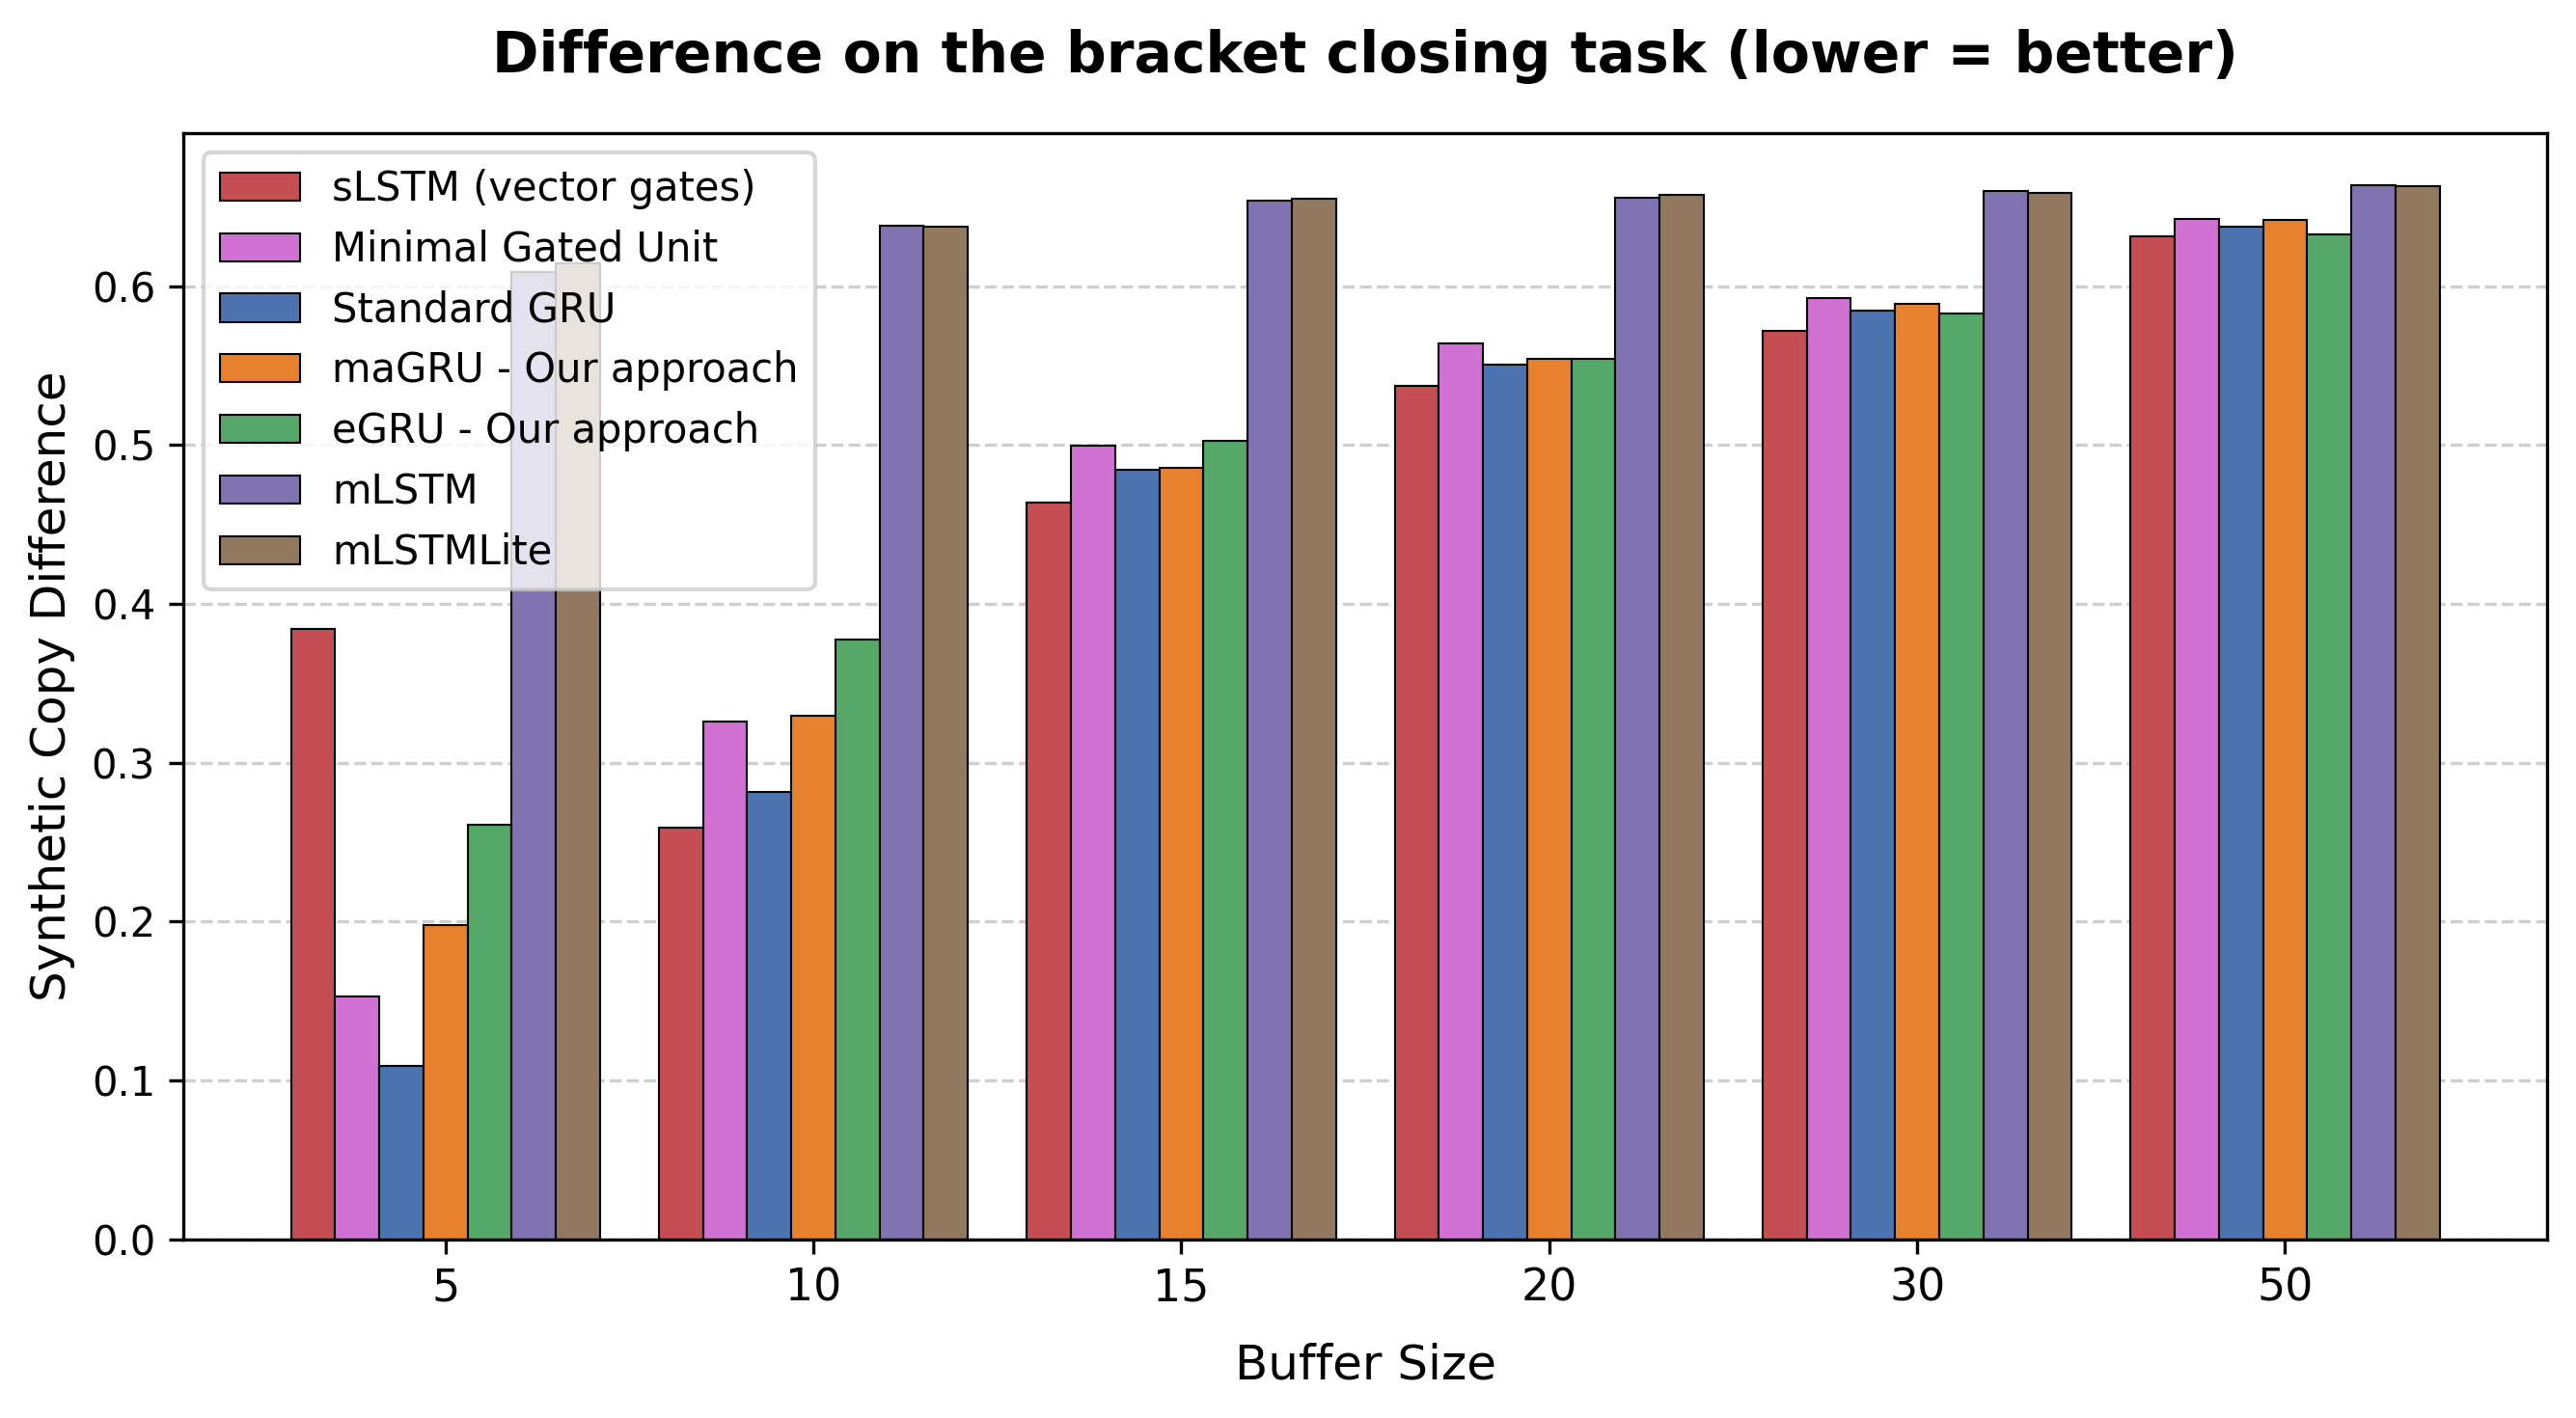

In [8]:
standard_gru = [
    0.10913779492499215,
     0.28147276557318057,
     0.48473390051634,
     0.5504620618159228,
     0.5849535766214428,
      0.6377190894419604
]

egru = [
    0.26099423710072395,
     0.37758662647540026,
     0.5026732571054213,
     0.5542656920924045,
     0.5830445395837917,
      0.6327822066769742
]

magru = [
    0.19797855792659344,
     0.3296039544119693,
     0.4858725135869319,
     0.5540924178491725,
     0.5886850103293315,
      0.6421324545794195
]

MGU = [
    0.15261964669617095,
     0.32599009086590003,
     0.499486377038578,
     0.5641749306480484,
     0.5929207784114497,
      0.6423304789137132
]

sLSTM = [
    0.38446784314542715,
     0.2590098953483128,
     0.4637066730768374,
     0.5376444004549839,
     0.5720606310532825,
      0.6313948312608322
]

mLSTM = [
    0.6092615841638924,
     0.6382796858796979,
     0.6539046864698429,
     0.6557797187625771,
     0.6598452831258869,
      0.6636374079354919
]
mLSTMLite = [
 0.6146246230248178,
  0.6373885970304508,
  0.655068054057584,
  0.6577475371927318,
  0.6589046870127763,
   0.6631609207332725
]


import matplotlib.pyplot as plt
import numpy as np

# Data
buffer_sizes = ["5", "10", "15", "20", "30", "50"]

# Plot setup
x = np.arange(len(buffer_sizes))


width = 0.12

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Create bars
rects0 = ax.bar(
    x - 3 * width,
    sLSTM,
    width,
    label="sLSTM (vector gates)",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.5,
)

rects1 = ax.bar(
    x - 2 * width,
    MGU,
    width,
    label="Minimal Gated Unit",
    color="#D071D3",
    edgecolor="black",
    linewidth=0.5,
)

rects2 = ax.bar(
    x - width,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

rects3 = ax.bar(
    x,
    magru,
    width,
    label="maGRU - Our approach",
    color="#E7812E",
    edgecolor="black",
    linewidth=0.5,
)

rects4 = ax.bar(
    x + width,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

rects5 = ax.bar(
    x + 2 * width,
    mLSTM,
    width,
    label="mLSTM",
    color="#8172B2",
    edgecolor="black",
    linewidth=0.5,
)

rects6 = ax.bar(
    x + 3 * width,
    mLSTMLite,
    width,
    label="mLSTMLite",
    color="#937860",
    edgecolor="black",
    linewidth=0.5,
)


# Titles and labels
ax.set_title(
    "Difference on the bracket closing task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Buffer Size",
    fontsize=12,
    fontweight="medium",
    labelpad=8,
)

ax.set_ylabel(
    "Synthetic Copy Difference",
    fontsize=12,
    fontweight="medium",
)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)

# Aesthetics
ax.legend(fontsize=10, frameon=True)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
